# Schémas d’Ozaki pour l’émulation de précision

Research projet CCA (M1) - Sorbonne Universite 2025-2026

**Anatole SAINERO & Thomas VEY**

Under supervision of **Théo MARY**

In this notebook, you will mostly find the code we used to study the algorithms and produce graphs showing some numerical properties.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import numpy.typing as npt
import math
import ml_dtypes
import warnings

import src.ozaki_1 as o1
import src.ozaki_2 as o2
import src.ozaki_2_hyb as o2h
import src.utils as utils
import src.baseline as baseline
from src.err_metrics import *
import src.esc as esc

## Ozaki-1

We will start by remaking the classical Ozaki-1 scheme, with the _numpy_ library, making sure to allow for type choice at any step in computation. 

For simplicity, it only takes f64 as input, and only gives f64 as final output.

We will mostly study f64 matrix multiplication using int8 matrices to decompose the input matrices, as this is the probably the idea most efficient in modern real case uses (with GPUs).  

In [2]:
# Here are the base functions we will use, and proof of functionality.

A = utils.random_matrix(3, 2, 5, 6, np.float64)
utils.print_matrix(A, name="A")

B = utils.random_matrix(2, 3, 0, 1, np.float64)
utils.print_matrix(B, name="B")
print("")

true_AB = baseline.get_exact_product(A, B, 256)
utils.print_matrix(true_AB, name="Perfect A.B")

normal_AB = A @ B
utils.print_matrix(normal_AB, name="Normal A.B")

sigma_A, sigma_B = 2**(np.frexp(np.max(np.abs(A))))[1], 2**(np.frexp(np.max(np.abs(B))))[1]
d = 7
ozaki1_split_A = o1.split_matrix_dtype(A, sigma_A, d, np.int8)
ozaki1_split_B = o1.split_matrix_dtype(B, sigma_B, d, np.int8)
ozaki1_product = o1.multiply_lists_dtype(ozaki1_split_A, ozaki1_split_B, np.int32)
ozaki1_AB = o1.sum_with_scaling(ozaki1_product, o1.get_scaling_factors(len(ozaki1_split_A), len(ozaki1_split_B), sigma_A, sigma_B, d))
utils.print_matrix(ozaki1_AB, name="Ozaki-1 A.B")

=================== A ====================
 | 5.718512230487464 | 5.366597463103346 |
 | 5.092715301487087 | 5.621086769586418 |
 | 5.968741300926078 | 5.413251314972705 |
=============================== B ===============================
 |  0.735415031830274 | 0.6603656709163719 | 0.2818867148158523 |
 | 0.8787617584055196 | 0.1802871275016847 | 0.6850099950867897 |

======================== Perfect A.B =========================
 | 8.921440477337047 | 4.743837606810064 | 5.288145528119584 |
 | 8.684855479337411 | 4.376463943979053 | 5.286069406245428 |
 | 9.146460318043628 | 4.917491383733455 | 5.390640133576759 |
========================= Normal A.B =========================
 | 8.921440477337047 | 4.743837606810063 | 5.288145528119584 |
 | 8.684855479337411 | 4.376463943979053 | 5.286069406245428 |
 | 9.146460318043628 | 4.917491383733455 | 5.390640133576759 |
======================== Ozaki-1 A.B =========================
 | 8.921440477337047 | 4.743837606810064 | 5.288145528119584 |

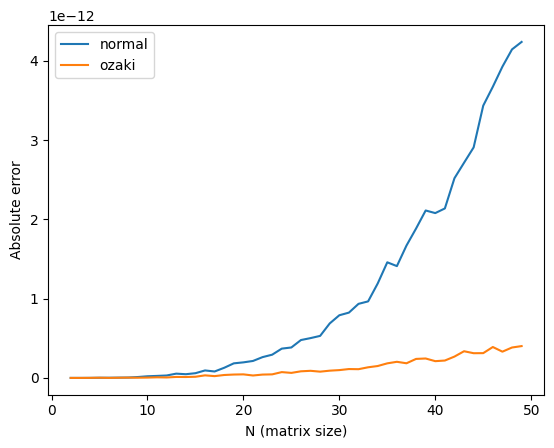

In [3]:
# This is a basic example of measurements we can do, not ot be seen as any good information.

n = np.arange(2, 50, 1, dtype=int)
errors = []
for i in n:
    A = utils.random_matrix(int(i), int(i), 0, 1, np.float64)
    B = utils.random_matrix(int(i), int(i), 0, 1, np.float64)
    true_AB = baseline.get_exact_product(A, B, 256)
    normal_AB = A @ B
    normal_AB_error = np.sum(np.abs(true_AB - normal_AB)) # VERY SIMPLE error measurement
    ozaki_AB = o1.full_ozaki_1(A, B, np.int8, 7, np.int32) # This function splits the matrices as much as is necessary to extract all the information
    ozaki_AB_error = np.sum(np.abs(true_AB - ozaki_AB))
    errors.append((normal_AB_error, ozaki_AB_error))

plt.plot(n, errors, label=("normal", "ozaki"))
plt.ylabel("Absolute error")
plt.xlabel("N (matrix size)")
plt.legend()
plt.show()


The above result can be explained by the precision errors in the final summation of the Ozaki-1 algorithm (absorption). Without better summation algorithms, it is quite complicated to get a better result.

We can also take a quick look on how the coefficient range impact error:

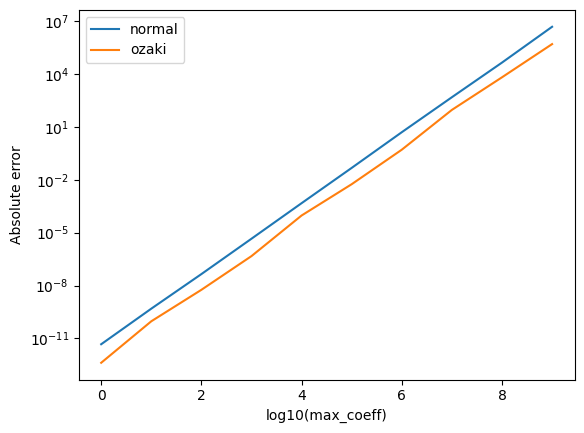

In [4]:
n = 50
errors = []
d = np.arange(10)
for i in d:
    A = utils.random_matrix(n, n, 0, 10.0 ** i, np.float64)
    B = utils.random_matrix(n, n, 0, 10.0 ** i, np.float64)
    true_AB = baseline.get_exact_product(A, B, 256)
    normal_AB = A @ B
    normal_AB_error = np.sum(np.abs(true_AB - normal_AB)) # VERY SIMPLE error measurement
    ozaki_AB = o1.full_ozaki_1(A, B, np.int8, 7, np.int32)
    ozaki_AB_error = np.sum(np.abs(true_AB - ozaki_AB))
    errors.append((normal_AB_error, ozaki_AB_error))

plt.semilogy(d, errors, label=("normal", "ozaki"))
plt.ylabel("Absolute error")
plt.xlabel("log10(max_coeff)")
plt.legend()
plt.show()

Naturally, we can see that more spreads matrices are more complicated to multiply correctly, but also that it is the same thing for classical multiplication. This will be studied in detail later

# Graphs production

We will probably not explain here what each graph means, but the titles and labels can help understand. 

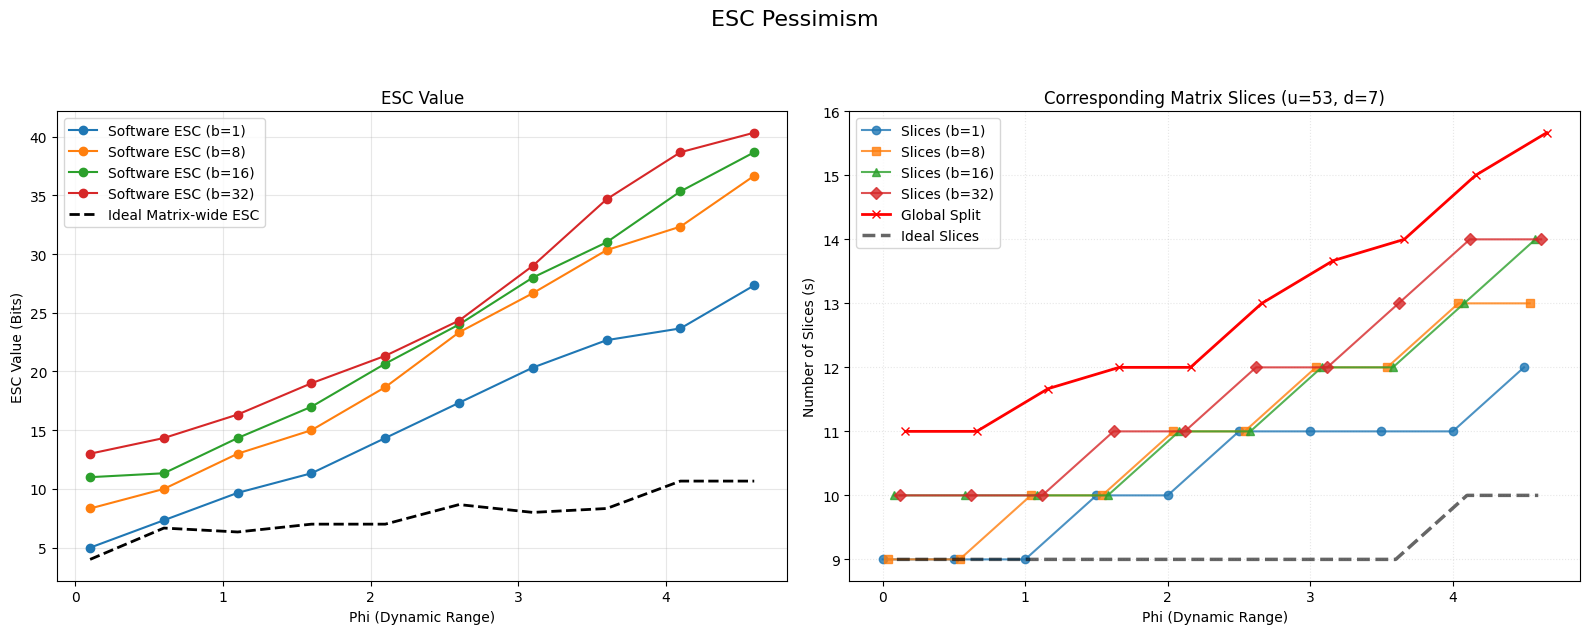

In [ ]:
# ESC value study compared to phi and number of slices it generates

from matplotlib.ticker import MaxNLocator  # For clean integer y-ticks

# --- PARAMETERS ---
N = 32
repeats = 3
phi_values = np.arange(0.1, 5.1, 0.5)
block_sizes = [1, 8, 16, 32] # not bigger than N (naturally)

# Hardware/Algorithm parameters
u = 53  # Target mantissa bits (FP64 parity)
d = 7   # Bits per slice (INT8)

# Store results
results_esc = {b: [] for b in block_sizes}
ideal_esc_results = []
global_split_slices = []

for x in phi_values:
    phi_accum = {b: 0.0 for b in block_sizes}
    ideal_accum = 0
    global_slices_accum = 0.0
    
    for _ in range(repeats):
        A = utils.random_phi_matrix(N, N, x, np.float64)
        B = utils.random_phi_matrix(N, N, x, np.float64)
        
        for b in block_sizes:
            phi_accum[b] += esc.esc(A, B, b=b) 
            
        C_exact = get_exact_product(A, B, 256)
        
        exp_A_max = np.max(np.frexp(A)[1])
        exp_B_max = np.max(np.frexp(B)[1])
        exp_C_max = np.max(np.frexp(C_exact)[1])
        
        # Ideal ESC with accumulation growth added back
        ideal_accum += (exp_A_max + exp_B_max - exp_C_max) + np.log2(N)
        
        # using global splitting, which means splitting each matrix independantly as long there is info to get,
        # how many slices would that use ?
        
        # Call the automatic splitting function to see how many slices it generates
        sigma_A = 2.0 ** (np.frexp(np.max(np.abs(A)))[1])
        sigma_B = 2.0 ** (np.frexp(np.max(np.abs(B)))[1])
        slices_A = o1.split_matrix_dtype(A, sigma_A, d, np.int8)
        slices_B = o1.split_matrix_dtype(B, sigma_B, d, np.int8)
        global_slices_accum += max(len(slices_A), len(slices_B))

    for b in block_sizes:
        results_esc[b].append(phi_accum[b] / repeats)
    ideal_esc_results.append(ideal_accum / repeats)
    global_split_slices.append(global_slices_accum / repeats)


results_slices = {
    b: [esc.esc_to_slices(val, d, u) for val in results_esc[b]] 
    for b in block_sizes
}
ideal_slices_results = [esc.esc_to_slices(val, d, u) for val in ideal_esc_results]

# --- PLOTTING ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Graph 1: ESC vs Phi
for b in block_sizes:
    ax1.plot(phi_values, results_esc[b], 'o-', label=f"Software ESC (b={b})")
ax1.plot(phi_values, ideal_esc_results, 'k--', linewidth=2, label="Ideal Matrix-wide ESC")

ax1.set_title(f"ESC Value")
ax1.set_xlabel("Phi (Dynamic Range)")
ax1.set_ylabel("ESC Value (Bits)")
ax1.grid(True, alpha=0.3)
ax1.legend()

# Graph 2: Slices vs Phi
# Distinct markers for each block size to help tell them apart visually
markers = ['o', 's', '^', 'D']

# We introduce a tiny x-shifting spread (dodging) so things don't overlap
# Spread out 4 blocks + 1 global split line cleanly across the 0.5 step size
total_groups = len(block_sizes) + 1 
spacing = 0.04 

# Plot the block sizes with individual X-offsets and custom markers
for idx, b in enumerate(block_sizes):
    x_offset = phi_values + (idx - (total_groups / 2)) * spacing
    ax2.plot(x_shift := x_offset, results_slices[b], marker=markers[idx], 
             linestyle='-', linewidth=1.5, alpha=0.8, label=f"Slices (b={b})")

# Plot Global Split on the far right of each data cluster
x_offset_global = phi_values + ((total_groups - 1) - (total_groups / 2)) * spacing
ax2.plot(x_offset_global, global_split_slices, 'r-x', linewidth=2, label="Global Split")

# Plot Ideal Slices as a clean, slightly wider background step/line without markers 
# so it acts as an anchor without adding point clutter
ax2.plot(phi_values, ideal_slices_results, 'k--', linewidth=2.5, alpha=0.6, label="Ideal Slices")

# Aesthetics & Readability Fixes
ax2.set_title(f"Corresponding Matrix Slices (u={u}, d={d})")
ax2.set_xlabel("Phi (Dynamic Range)")
ax2.set_ylabel("Number of Slices (s)")

# Force the Y-axis to ONLY show clean integer ticks (no 10.5 or 12.25 slices)
ax2.yaxis.set_major_locator(MaxNLocator(integer=True))

ax2.grid(True, which="both", alpha=0.3, linestyle=":")
ax2.legend(loc='best')

plt.suptitle(f"ESC Pessimism", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

<>:92: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:92: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
/tmp/ipykernel_54544/918889891.py:92: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  plt.xlabel(f"$\phi$ of Matrix B (Matrix A fixed at {fixed_phi_A})", fontsize=12)


Running Asymmetric Experiment (Simple A vs. Bad B) with Ideal Comparison...


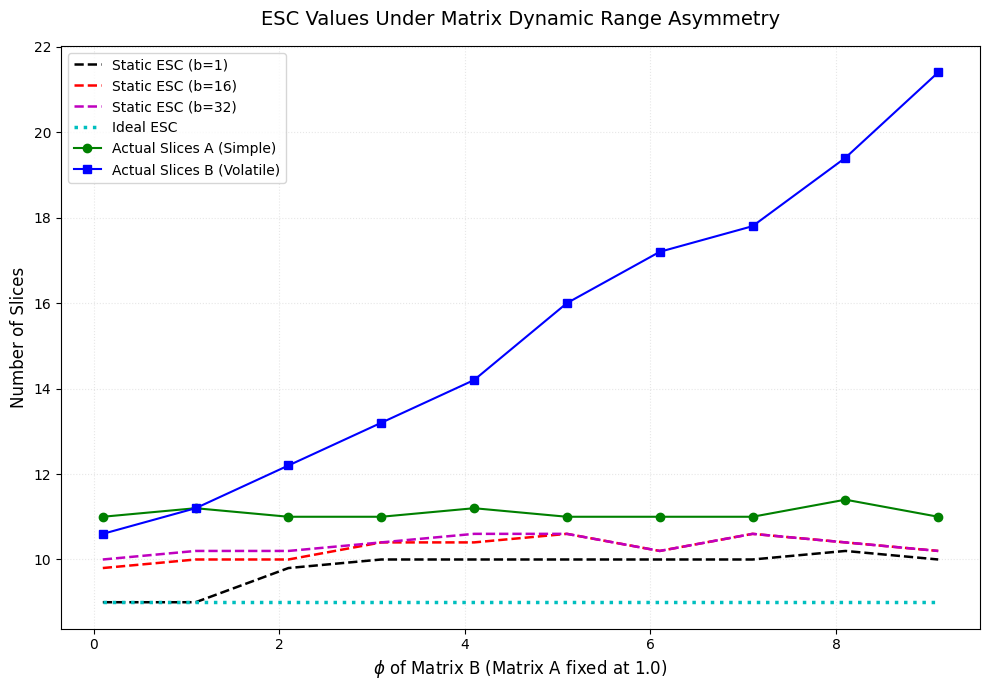

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# --- PARAMETERS ---
N = 32
repeats = 5
phi_B_values = np.arange(0.1, 10.1, 1)

# Fix Matrix A to be incredibly simple (Low dynamic range)
fixed_phi_A = 1.0

# Hardware/Algorithm parameters
u = 53  
d = 7   

# Track multiple b values for ESC
b_values = [1, 16, 32]

# Accumulators for dynamic tracks
actual_slices_A_track = []
actual_slices_B_track = []

# Accumulators for different ESC configurations and Ideal case
esc_slices_tracks = {b: [] for b in b_values}
ideal_slices_track = []

print("Running Asymmetric Experiment (Simple A vs. Bad B) with Ideal Comparison...")
for phi_B in phi_B_values:
    # Initialize accumulators for this phi_B step
    s_A_accum = 0.0
    s_B_accum = 0.0
    ideal_accum = 0.0
    esc_accums = {b: 0.0 for b in b_values}
    
    for _ in range(repeats):
        # A is clean and uniform; B is highly volatile
        A = utils.random_phi_matrix(N, N, fixed_phi_A, np.float64)
        B = utils.random_phi_matrix(N, N, phi_B, np.float64)
        
        # 1. Compute dynamic remainder loop slices
        sigma_A = 2.0 ** (np.frexp(np.max(np.abs(A)))[1])
        sigma_B = 2.0 ** (np.frexp(np.max(np.abs(B)))[1])
        
        slices_A = o1.split_matrix_dtype(A, sigma_A, d, np.int8)
        slices_B = o1.split_matrix_dtype(B, sigma_B, d, np.int8)
        
        s_A_accum += len(slices_A)
        s_B_accum += len(slices_B)
        
        # 2. Compute static ESC dictates for each block size 'b'
        for b in b_values:
            raw_esc = esc.esc(A, B, b=b)
            esc_accums[b] += esc.esc_to_slices(raw_esc, d, u)
            
        # 3. Compute Ideal ESC based on exact product dynamic range
        C_exact = baseline.get_exact_product(A, B, 256)
        
        exp_A_max = np.max(np.frexp(A)[1])
        exp_B_max = np.max(np.frexp(B)[1])
        exp_C_max = np.max(np.frexp(C_exact)[1])
        
        raw_ideal_esc = (exp_A_max + exp_B_max - exp_C_max) + np.log2(N)
        ideal_accum += esc.esc_to_slices(raw_ideal_esc, d, u)

    # Average data across repetitions
    actual_slices_A_track.append(s_A_accum / repeats)
    actual_slices_B_track.append(s_B_accum / repeats)
    ideal_slices_track.append(ideal_accum / repeats)
    
    for b in b_values:
        esc_slices_tracks[b].append(esc_accums[b] / repeats)

# --- PLOTTING ---
plt.figure(figsize=(10, 7))

# 1. Plot Block-based Static ESC Configurations
esc_styles = {1: ('k--', '1.0'), 16: ('r--', '0.8'), 32: ('m--', '0.6')}
for b in b_values:
    style, alpha = esc_styles[b]
    plt.plot(phi_B_values, esc_slices_tracks[b], style, linewidth=1.8, 
             label=f"Static ESC (b={b})")

# 2. Plot Ideal ESC Baseline
plt.plot(phi_B_values, ideal_slices_track, 'c:', linewidth=2.5, 
         label="Ideal ESC")

# 3. Plot Actual Dense Dynamic Slices Generated
plt.plot(phi_B_values, actual_slices_A_track, 'g-o', linewidth=1.5, label="Actual Slices A (Simple)")
plt.plot(phi_B_values, actual_slices_B_track, 'b-s', linewidth=1.5, label="Actual Slices B (Volatile)")

plt.title("ESC Values Under Matrix Dynamic Range Asymmetry", fontsize=14, pad=15)
plt.xlabel(f"$\phi$ of Matrix B (Matrix A fixed at {fixed_phi_A})", fontsize=12)
plt.ylabel("Number of Slices", fontsize=12)
plt.grid(True, alpha=0.3, linestyle=':')
plt.legend(fontsize=10, loc="upper left")

plt.tight_layout()
plt.show()

The graph below is trying to reproduce fig 1 of the "Ozaki Scheme II: A GEMM-oriented emulation of floating-point matrix multiplication using an integer modular technique" article (2504.08009v3), a graph showing how Ozaki-1 behaves in its number of slices/GEMMs.

Repeat 10/10

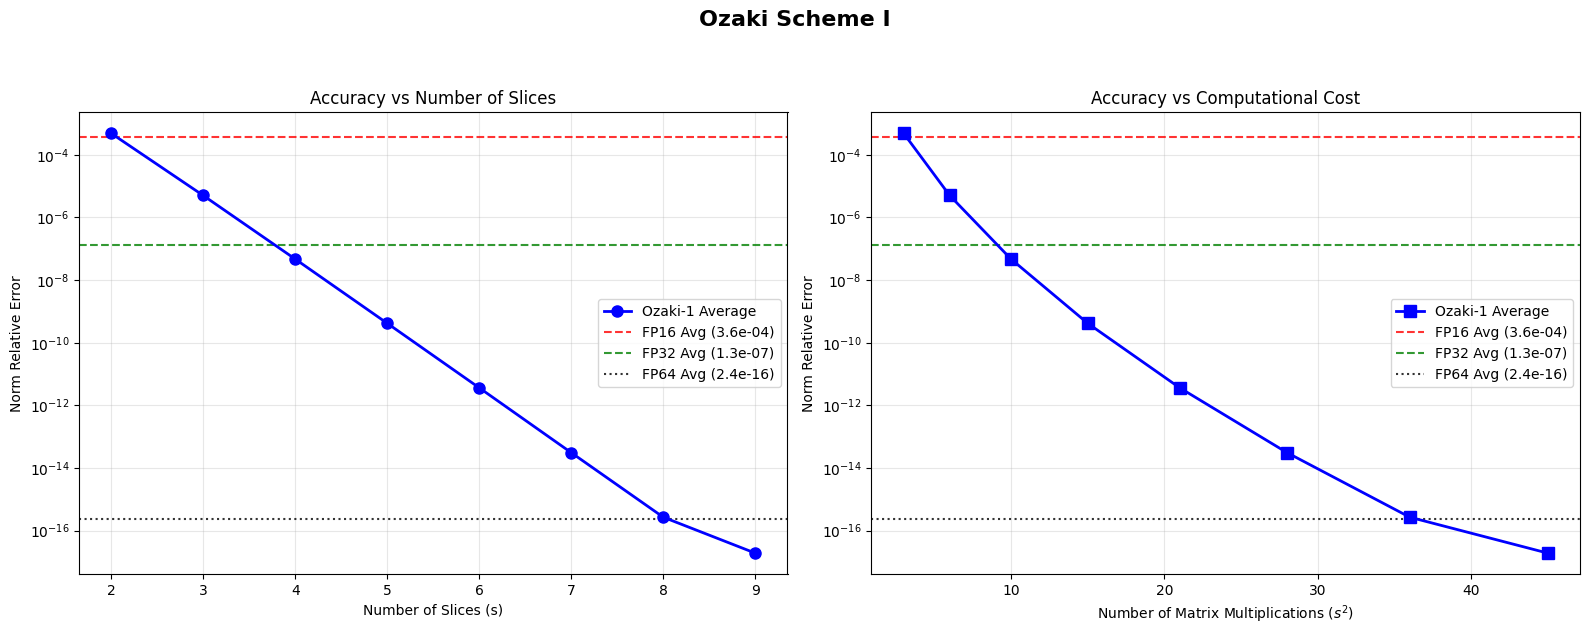

In [15]:
# --- PARAMETERS ---
i_range = range(2, 10)
repeats = 10
N = 50

# Accumulators for averages
error_f16, error_f32, error_f64 = 0.0, 0.0, 0.0
errors_ozaki_avg = [0.0 for _ in i_range]

# --- NEW: Lists to store individual discrete runs ---
all_errors_ozaki = {s: [] for s in i_range}
all_errors_f16 = []
all_errors_f32 = []
all_errors_f64 = []

for r in range(repeats):
    print(f"\rRepeat {r + 1}/{repeats}", end="")
    A = utils.random_mean_var_matrix(N, N, np.float64)
    B = utils.random_mean_var_matrix(N, N, np.float64)

    perfect = baseline.get_exact_product(A, B, 192)
    
    # Calculate and store baseline errors
    err_16 = forward_error(A, B, A.astype(np.float16) @ B.astype(np.float16), C=perfect)
    err_32 = forward_error(A, B, A.astype(np.float32) @ B.astype(np.float32), C=perfect)
    err_64 = forward_error(A, B, A @ B, C=perfect)
    
    error_f16 += err_16
    error_f32 += err_32
    error_f64 += err_64
    
    all_errors_f16.append(err_16)
    all_errors_f32.append(err_32)
    all_errors_f64.append(err_64)

    # Calculate and store individual Ozaki errors
    for (i, s) in enumerate(i_range):
        err_oz = forward_error(A, B, o1.full_ozaki_1_fast(A, B, np.int8, 7, np.int32, s), C=perfect)
        errors_ozaki_avg[i] += err_oz
        all_errors_ozaki[s].append(err_oz)

# Finalize averages
error_f16 /= repeats
error_f32 /= repeats
error_f64 /= repeats
errors_ozaki_avg = [a / repeats for a in errors_ozaki_avg]

# --- PLOTTING LOGIC ---
num_mults = [s*(s + 1) / 2 for s in i_range]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Relative Error vs Number of Slices (Left)

# Plot the average line on top
ax1.semilogy(i_range, errors_ozaki_avg, 'b-o', linewidth=2, markersize=8, zorder=3, label='Ozaki-1 Average')

ax1.axhline(y=error_f16, color='red', linestyle='--', alpha=0.8, label=f'FP16 Avg ({error_f16:.1e})')
ax1.axhline(y=error_f32, color='green', linestyle='--', alpha=0.8, label=f'FP32 Avg ({error_f32:.1e})')
ax1.axhline(y=error_f64, color='black', linestyle=':', alpha=0.8, label=f'FP64 Avg ({error_f64:.1e})')

ax1.set_xlabel('Number of Slices (s)')
ax1.set_ylabel('Norm Relative Error')
ax1.set_title('Accuracy vs Number of Slices')
ax1.grid(True, which="both", ls="-", alpha=0.3)
# We only add the scatter label once to avoid cluttering the legend
# ax1.scatter([], [], color='dodgerblue', alpha=0.4, s=30, label='Individual Matrix Runs')
ax1.legend(loc='best')

# Plot 2: Relative Error vs Number of Matrix Multiplications (Right)
ax2.semilogy(num_mults, errors_ozaki_avg, 'b-s', linewidth=2, markersize=8, zorder=3, label='Ozaki-1 Average')

ax2.axhline(y=error_f16, color='red', linestyle='--', alpha=0.8, label=f'FP16 Avg ({error_f16:.1e})')
ax2.axhline(y=error_f32, color='green', linestyle='--', alpha=0.8, label=f'FP32 Avg ({error_f32:.1e})')
ax2.axhline(y=error_f64, color='black', linestyle=':', alpha=0.8, label=f'FP64 Avg ({error_f64:.1e})')

ax2.set_xlabel('Number of Matrix Multiplications ($s^2$)')
ax2.set_ylabel('Norm Relative Error')
ax2.set_title('Accuracy vs Computational Cost')
ax2.grid(True, which="both", ls="-", alpha=0.3)
# ax2.scatter([], [], color='dodgerblue', alpha=0.4, s=30, label='Individual Matrix Runs')
ax2.legend(loc='best')

plt.suptitle('Ozaki Scheme I', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

Evaluating Phi = 4.6...

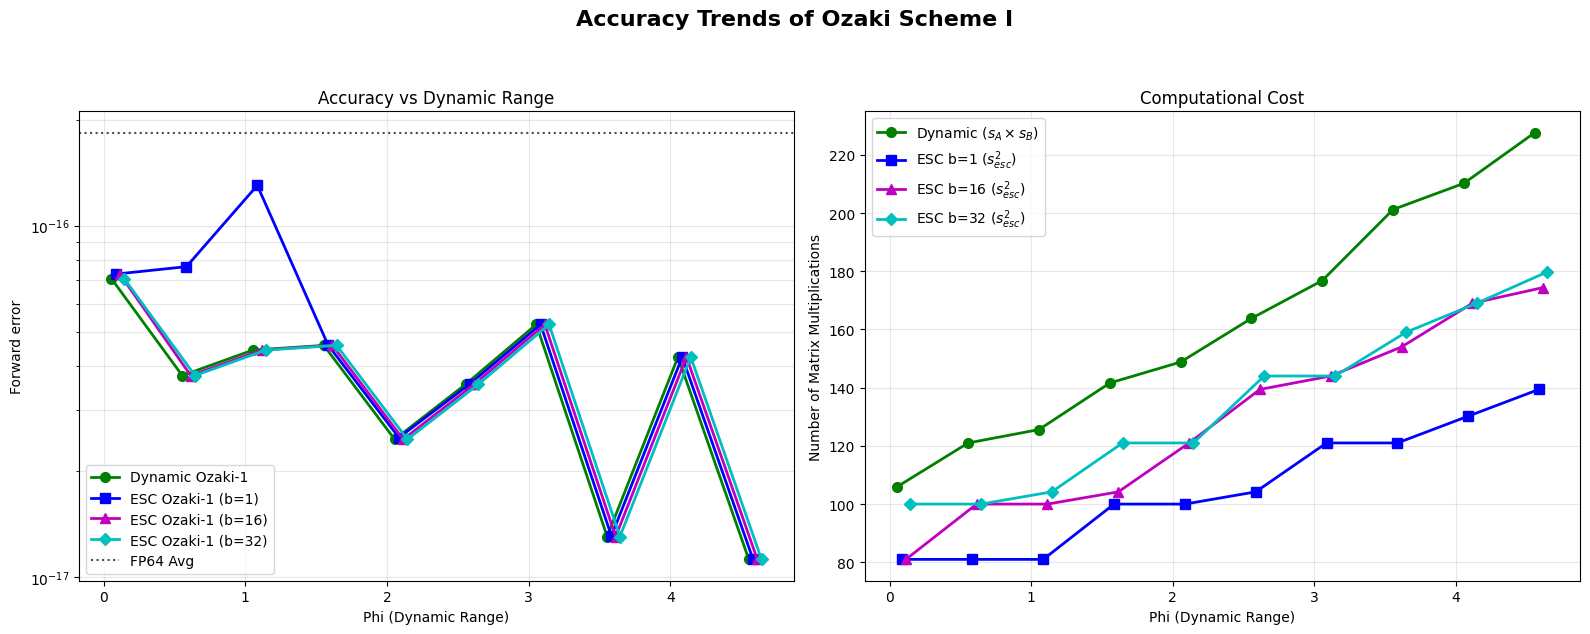

In [16]:
# This graph was used to observe how Ozaki 1 using ESC to determine the number of slices was behaving. 
# The conclusion is simple : it does work for any value of b, with no really visible differences in our case... 
# (which we know isn't true, a less coarsened ESC version should produce higher errors)

# --- PARAMETERS ---
N = 32
phi_values = np.arange(0.1, 5.1, 0.5)
repeats = 5

# Hardware/Algorithm parameters
u = 53  # Target precision bits (FP64 parity)
d = 7   # Bits per slice (INT8)

# Accumulators for Errors
error_f64 = []
errors_dynamic = []
errors_esc_b1 = []
errors_esc_b16 = []
errors_esc_b32 = []  

# Accumulators for Cost (Total Inner Matrix Multiplications)
mults_dynamic = []
mults_esc_b1 = []
mults_esc_b16 = []
mults_esc_b32 = []  # Added b=32

for x in phi_values:
    print(f"\rEvaluating Phi = {x:.1f}...", end="")
    
    # Temporary accumulators for averaging current phi level
    err_f32_acc = 0.0
    err_f64_acc = 0.0
    err_dyn_acc, err_b1_acc, err_b16_acc, err_b32_acc = 0.0, 0.0, 0.0, 0.0
    cost_dyn_acc, cost_b1_acc, cost_b16_acc, cost_b32_acc = 0.0, 0.0, 0.0, 0.0
    
    for _ in range(repeats):
        A = utils.random_phi_matrix(N, N, x, np.float64)
        B = utils.random_phi_matrix(N, N, x, np.float64)

        perfect = baseline.get_exact_product(A, B, 192)
        
        # 1. Standard Floating Point Baselines
        err_f64_acc += forward_error(A, B, A @ B, C=perfect)

        # 2. Dynamic Splitting (Stops automatically when remainder is zero)
        sigma_A = 2.0 ** (np.frexp(np.max(np.abs(A)))[1])
        sigma_B = 2.0 ** (np.frexp(np.max(np.abs(B)))[1])
        s_A = len(o1.split_matrix_dtype(A, sigma_A, d, np.int8))
        s_B = len(o1.split_matrix_dtype(B, sigma_B, d, np.int8))
        
        res_dynamic = o1.full_ozaki_1(A, B, np.int8, d, np.int32)
        err_dyn_acc += forward_error(A, B, res_dynamic, C=perfect)
        cost_dyn_acc += s_A * s_B  # True asymmetric multiplication cost

        # 3. ESC Tracking (b=1)
        esc_b1 = esc.esc(A, B, b=1)
        s_esc_b1 = esc.esc_to_slices(esc_b1, d, u)
        
        res_esc_b1 = o1.full_ozaki_1_auto_esc(A, B, np.int8, d, np.int32, b=1)
        err_b1_acc += forward_error(A, B, res_esc_b1, C=perfect)
        cost_b1_acc += s_esc_b1 * s_esc_b1  # Symmetric cost metric

        # 4. ESC Tracking (b=16)
        esc_b16 = esc.esc(A, B, b=16)
        s_esc_b16 = esc.esc_to_slices(esc_b16, d, u)
        
        res_esc_b16 = o1.full_ozaki_1_auto_esc(A, B, np.int8, d, np.int32, b=16)
        err_b16_acc += forward_error(A, B, res_esc_b16, C=perfect)
        cost_b16_acc += s_esc_b16 * s_esc_b16  # Symmetric cost metric

        # 5. ESC Tracking (b=32)
        esc_b32 = esc.esc(A, B, b=32)
        s_esc_b32 = esc.esc_to_slices(esc_b32, d, u)
        
        res_esc_b32 = o1.full_ozaki_1_auto_esc(A, B, np.int8, d, np.int32, b=32)
        err_b32_acc += forward_error(A, B, res_esc_b32, C=perfect)
        cost_b32_acc += s_esc_b32 * s_esc_b32  # Symmetric cost metric

    # Calculate means
    error_f64.append(err_f64_acc / repeats)
    
    errors_dynamic.append(err_dyn_acc / repeats)
    errors_esc_b1.append(err_b1_acc / repeats)
    errors_esc_b16.append(err_b16_acc / repeats)
    errors_esc_b32.append(err_b32_acc / repeats)
    
    mults_dynamic.append(cost_dyn_acc / repeats)
    mults_esc_b1.append(cost_b1_acc / repeats)
    mults_esc_b16.append(cost_b16_acc / repeats)
    mults_esc_b32.append(cost_b32_acc / repeats)

# --- PLOTTING LOGIC ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Define clean spacing for dodging 4 curves across the x-axis
spacing = 0.03
offsets = [-1.5 * spacing, -0.5 * spacing, 0.5 * spacing, 1.5 * spacing]

# Plot 1: Relative Error vs Phi (Left) with X-shifts
ax1.semilogy(phi_values + offsets[0], errors_dynamic, 'g-o', linewidth=2, markersize=7, label='Dynamic Ozaki-1')
ax1.semilogy(phi_values + offsets[1], errors_esc_b1, 'b-s', linewidth=2, markersize=7, label='ESC Ozaki-1 (b=1)')
ax1.semilogy(phi_values + offsets[2], errors_esc_b16, 'm-^', linewidth=2, markersize=7, label='ESC Ozaki-1 (b=16)')
ax1.semilogy(phi_values + offsets[3], errors_esc_b32, 'c-D', linewidth=2, markersize=6, label='ESC Ozaki-1 (b=32)')

ax1.axhline(y=np.mean(error_f64), color='black', linestyle=':', alpha=0.7, label='FP64 Avg')

ax1.set_xlabel('Phi (Dynamic Range)')
ax1.set_ylabel('Forward error')
ax1.set_title('Accuracy vs Dynamic Range')
ax1.grid(True, which="both", ls="-", alpha=0.3)
ax1.legend(loc='best')

# Plot 2: Total Matrix Multiplications vs Phi (Right) with X-shifts
ax2.plot(phi_values + offsets[0], mults_dynamic, 'g-o', linewidth=2, markersize=7, label='Dynamic ($s_A \\times s_B$)')
ax2.plot(phi_values + offsets[1], mults_esc_b1, 'b-s', linewidth=2, markersize=7, label='ESC b=1 ($s_{esc}^2$)')
ax2.plot(phi_values + offsets[2], mults_esc_b16, 'm-^', linewidth=2, markersize=7, label='ESC b=16 ($s_{esc}^2$)')
ax2.plot(phi_values + offsets[3], mults_esc_b32, 'c-D', linewidth=2, markersize=6, label='ESC b=32 ($s_{esc}^2$)')

ax2.set_xlabel('Phi (Dynamic Range)')
ax2.set_ylabel('Number of Matrix Multiplications')
ax2.set_title('Computational Cost')
ax2.grid(True, which="both", ls="-", alpha=0.3)
ax2.legend(loc='best')

plt.suptitle('Accuracy Trends of Ozaki Scheme I', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

Repeat 3/3

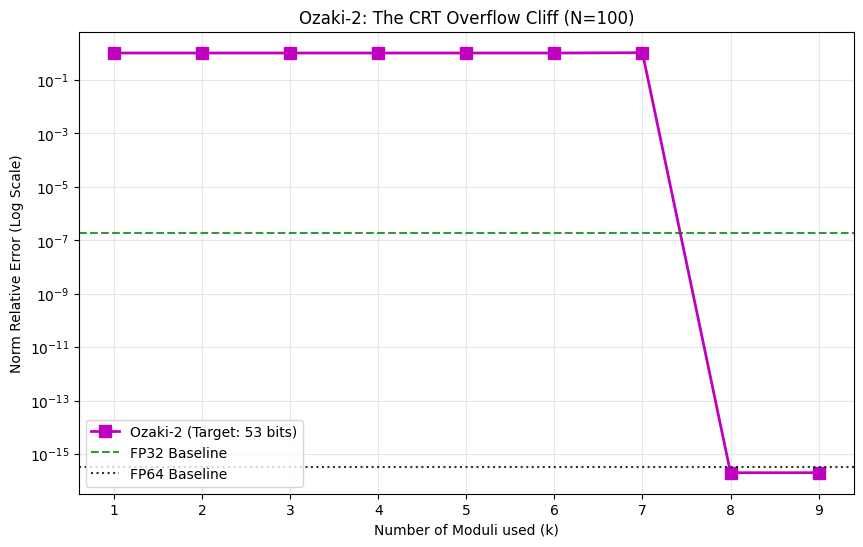

In [ ]:
# This shows how, at fixed target, Ozaki-2 doesn't work at all if it doesn't have enough moduli. 
# This means we have to use dynamic target bit size if we want to test compared to moduli number 
# (this target_bit is used for the scaling)

N = 100
repeats = 3

target_bits = 53 # similar to fp64 

k_range = range(1, 9 + 1) # range of number of moduli

errors_ozaki2 = [0.0 for _ in k_range]
error_f32 = 0.0
error_f64 = 0.0

for r in range(repeats):
    print(f"\rRepeat {r + 1}/{repeats}", end="")
    A = utils.random_mean_var_matrix(N, N, np.float64)
    B = utils.random_mean_var_matrix(N, N, np.float64)
    perfect = baseline.get_exact_product(A, B, 192)

    error_f32 += forward_error(A, B, A.astype(np.float32) @ B.astype(np.float32), C=perfect)
    error_f64 += forward_error(A, B, A @ B, C=perfect)

    for k in k_range:
        # Calculate using k moduli
        res = o2.full_ozaki_2(A, B, target_bits, k, np.int16, np.int64)
        
        errors_ozaki2[k - 1] += forward_error(A, B, res, C=perfect)

# Average the results
errors_ozaki2 = [err / repeats for err in errors_ozaki2]
error_f32 /= repeats
error_f64 /= repeats

# --- Plotting ---
plt.figure(figsize=(10, 6))

plt.semilogy(k_range, errors_ozaki2, 'm-s', linewidth=2, markersize=8, label=f'Ozaki-2 (Target: {target_bits} bits)')

plt.axhline(y=error_f32, color='green', linestyle='--', alpha=0.8, label=f'FP32 Baseline')
plt.axhline(y=error_f64, color='black', linestyle=':', alpha=0.8, label=f'FP64 Baseline')

plt.xlabel('Number of Moduli used (k)')
plt.ylabel('Norm Relative Error (Log Scale)')
plt.title(f'Ozaki-2: The CRT Overflow Cliff (N={N})')
plt.xticks(k_range)
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.legend(loc='best')
plt.show()

Testing Phi = 7.5...

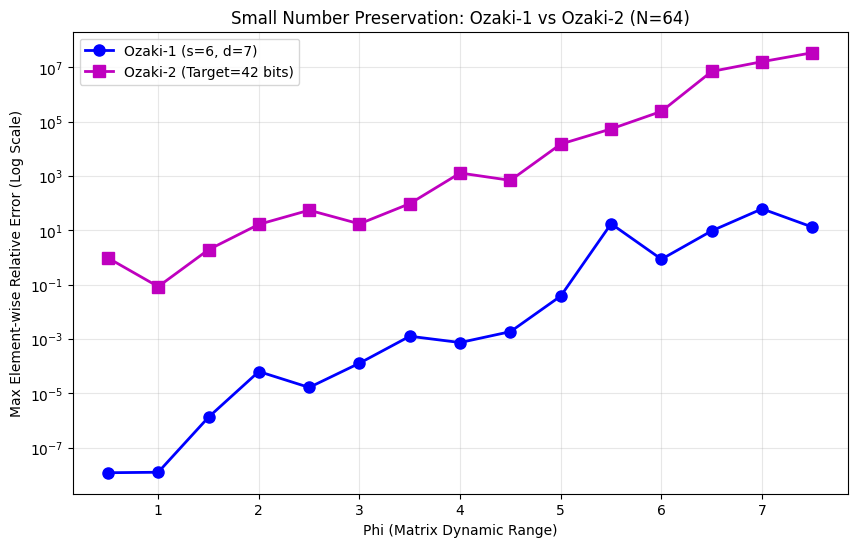

In [ ]:
# Comparison between the two schemes for worse error 
# Are pretty similar, just a constant of difference, and o2 uses less multiplications anyway.

N = 64
repeats = 3

# Phi controls the exponent range. 
# Low phi = numbers are similar size. High phi = massive and tiny numbers mixed.
phi_values = np.arange(0.5, 8, 0.5)

# Equal Precision Budgets
o1_slices = 6
o1_depth = 7         # 6 * 7 = 42 bits of depth
o2_target_bits = 42  # 42 bits of depth

nb_moduli = 10

errors_o1 = []
errors_o2 = []

for phi in phi_values:
    print(f"\rTesting Phi = {phi:.1f}...", end="")
    err_o1_accum = 0.0
    err_o2_accum = 0.0
    
    for _ in range(repeats):
        A = utils.random_phi_matrix(N, N, phi, np.float64)
        B = utils.random_phi_matrix(N, N, phi, np.float64)
        perfect = baseline.get_exact_product(A, B, 256)
        
        # Ozaki-1
        res_o1 = o1.full_ozaki_1_trunc(A, B, np.int8, o1_depth, np.int32, o1_slices)
        err_o1_accum += max_relative_error(A, B, res_o1, perfect)
        
        # Ozaki-2
        res_o2 = o2.full_ozaki_2(A, B, o2_target_bits, nb_moduli, np.int32, np.int64)
        err_o2_accum += max_relative_error(A, B, res_o2, perfect)
        
    errors_o1.append(err_o1_accum / repeats)
    errors_o2.append(err_o2_accum / repeats)

# --- Plotting ---
plt.figure(figsize=(10, 6))

plt.semilogy(phi_values, errors_o1, 'b-o', linewidth=2, markersize=8, label=f'Ozaki-1 (s={o1_slices}, d={o1_depth})')
plt.semilogy(phi_values, errors_o2, 'm-s', linewidth=2, markersize=8, label=f'Ozaki-2 (Target={o2_target_bits} bits)')

plt.xlabel('Phi (Matrix Dynamic Range)')
plt.ylabel('Max Element-wise Relative Error (Log Scale)')
plt.title(f'Small Number Preservation: Ozaki-1 vs Ozaki-2 (N={N})')
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.legend(loc='best')
plt.show()

Repeat 1/10
Repeat 2/10
Repeat 3/10
Repeat 4/10
Repeat 5/10
Repeat 6/10
Repeat 7/10
Repeat 8/10
Repeat 9/10
Repeat 10/10


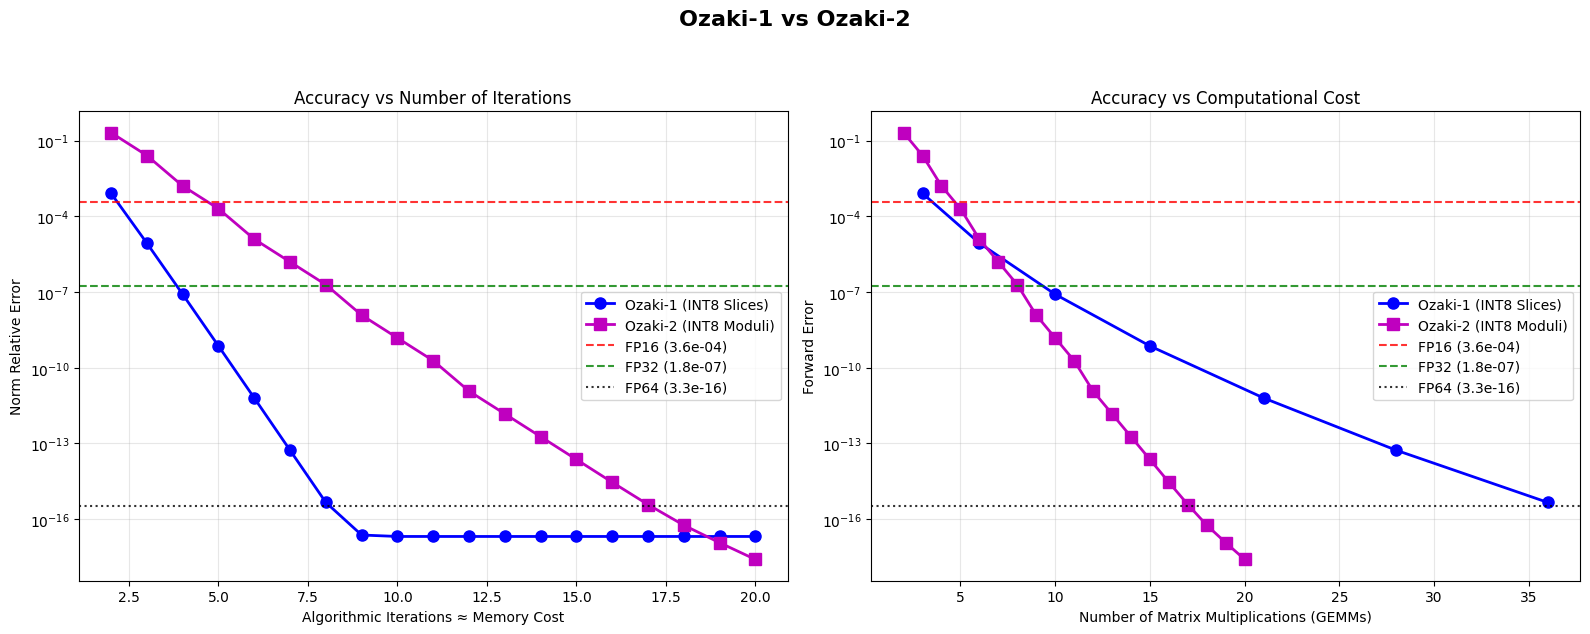

In [18]:
# --- The Ultimate Showdown Benchmark ---

i_range = range(2, 21)
N = 100
repeats = 10

error_f16, error_f32, error_f64 = 0.0, 0.0, 0.0
errors_o1 = [0.0 for _ in i_range]
errors_o2 = [0.0 for _ in i_range]

for r in range(repeats):
    print(f"Repeat {r + 1}/{repeats}")
    A = utils.random_mean_var_matrix(N, N, np.float64)
    B = utils.random_mean_var_matrix(N, N, np.float64)

    perfect = baseline.get_exact_product(A, B, 192)
    error_f16 += forward_error(A, B, A.astype(np.float16) @ B.astype(np.float16), C=perfect)
    error_f32 += forward_error(A, B, A.astype(np.float32) @ B.astype(np.float32), C=perfect)
    error_f64 += forward_error(A, B, A @ B, C=perfect)

    for (idx, i) in enumerate(i_range):
        # --- 1. Ozaki-1 (INT8 Slices) ---
        res_o1 = o1.full_ozaki_1_fast(A, B, np.int8, 7, np.int32, i)
        errors_o1[idx] += forward_error(A, B, res_o1, C=perfect)

        # --- 2. Ozaki-2 (INT16 Moduli) ---
        # Calculate the maximum safe precision we can target with `i` moduli.
        # NOT SURE I UNDERSTAND THAT FOR NOW
        actual_moduli = o2.get_moduli_universal(np.int8, i, q=N) # For INT8
        true_capacity_bits = sum(np.log2(m) for m in actual_moduli)
        max_target_bits = int((true_capacity_bits - np.log2(N) - 1) / 2.0)
        max_target_bits = max(1, max_target_bits)

        res_o2 = o2.full_ozaki_2(A, B, max_target_bits, i, np.int8, np.int32)
        errors_o2[idx] += forward_error(A, B, res_o2, C=perfect)

error_f16 /= repeats
error_f32 /= repeats
error_f64 /= repeats
errors_o1 = [a / repeats for a in errors_o1]
errors_o2 = [a / repeats for a in errors_o2]

# --- PLOTTING LOGIC ---

# Computational cost (GEMMs)
mults_o1 = [s * (s + 1) / 2 for s in i_range]  # Triangular cost
mults_o2 = [k for k in i_range]                # Linear cost (1 GEMM per modulus)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Relative Error vs Iterations (Slices/Moduli)
ax1.semilogy(i_range, errors_o1, 'b-o', linewidth=2, markersize=8, label='Ozaki-1 (INT8 Slices)')
ax1.semilogy(i_range, errors_o2, 'm-s', linewidth=2, markersize=8, label='Ozaki-2 (INT8 Moduli)')

ax1.axhline(y=error_f16, color='red', linestyle='--', alpha=0.8, label=f'FP16 ({error_f16:.1e})')
ax1.axhline(y=error_f32, color='green', linestyle='--', alpha=0.8, label=f'FP32 ({error_f32:.1e})')
ax1.axhline(y=error_f64, color='black', linestyle=':', alpha=0.8, label=f'FP64 ({error_f64:.1e})')

ax1.set_xlabel('Algorithmic Iterations ≈ Memory Cost')
ax1.set_ylabel('Norm Relative Error')
ax1.set_title('Accuracy vs Number of Iterations')
ax1.grid(True, which="both", ls="-", alpha=0.3)
ax1.legend(loc='best')

# Plot 2: Relative Error vs Computational Cost (GEMMs)
ax2.semilogy(mults_o1[:7], errors_o1[:7], 'b-o', linewidth=2, markersize=8, label='Ozaki-1 (INT8 Slices)')
ax2.semilogy(mults_o2, errors_o2, 'm-s', linewidth=2, markersize=8, label='Ozaki-2 (INT8 Moduli)')

ax2.axhline(y=error_f16, color='red', linestyle='--', alpha=0.8, label=f'FP16 ({error_f16:.1e})')
ax2.axhline(y=error_f32, color='green', linestyle='--', alpha=0.8, label=f'FP32 ({error_f32:.1e})')
ax2.axhline(y=error_f64, color='black', linestyle=':', alpha=0.8, label=f'FP64 ({error_f64:.1e})')

ax2.set_xlabel('Number of Matrix Multiplications (GEMMs)')
ax2.set_ylabel('Forward Error')
ax2.set_title('Accuracy vs Computational Cost')
ax2.grid(True, which="both", ls="-", alpha=0.3)
ax2.legend(loc='best')

plt.suptitle('Ozaki-1 vs Ozaki-2', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

<>:7: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:7: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:7: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:7: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:7: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:7: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
/tmp/ipykernel_42729/1234316311.py:7: SyntaxWarning: "\p" is an invalid escape seq

--- Executing Figure 3 Benchmark (Error vs Number of Moduli) ---
Testing Condition: Std. normal...
Testing Condition: 1.0...
Testing Condition: 2.0...
Testing Condition: 4.0...


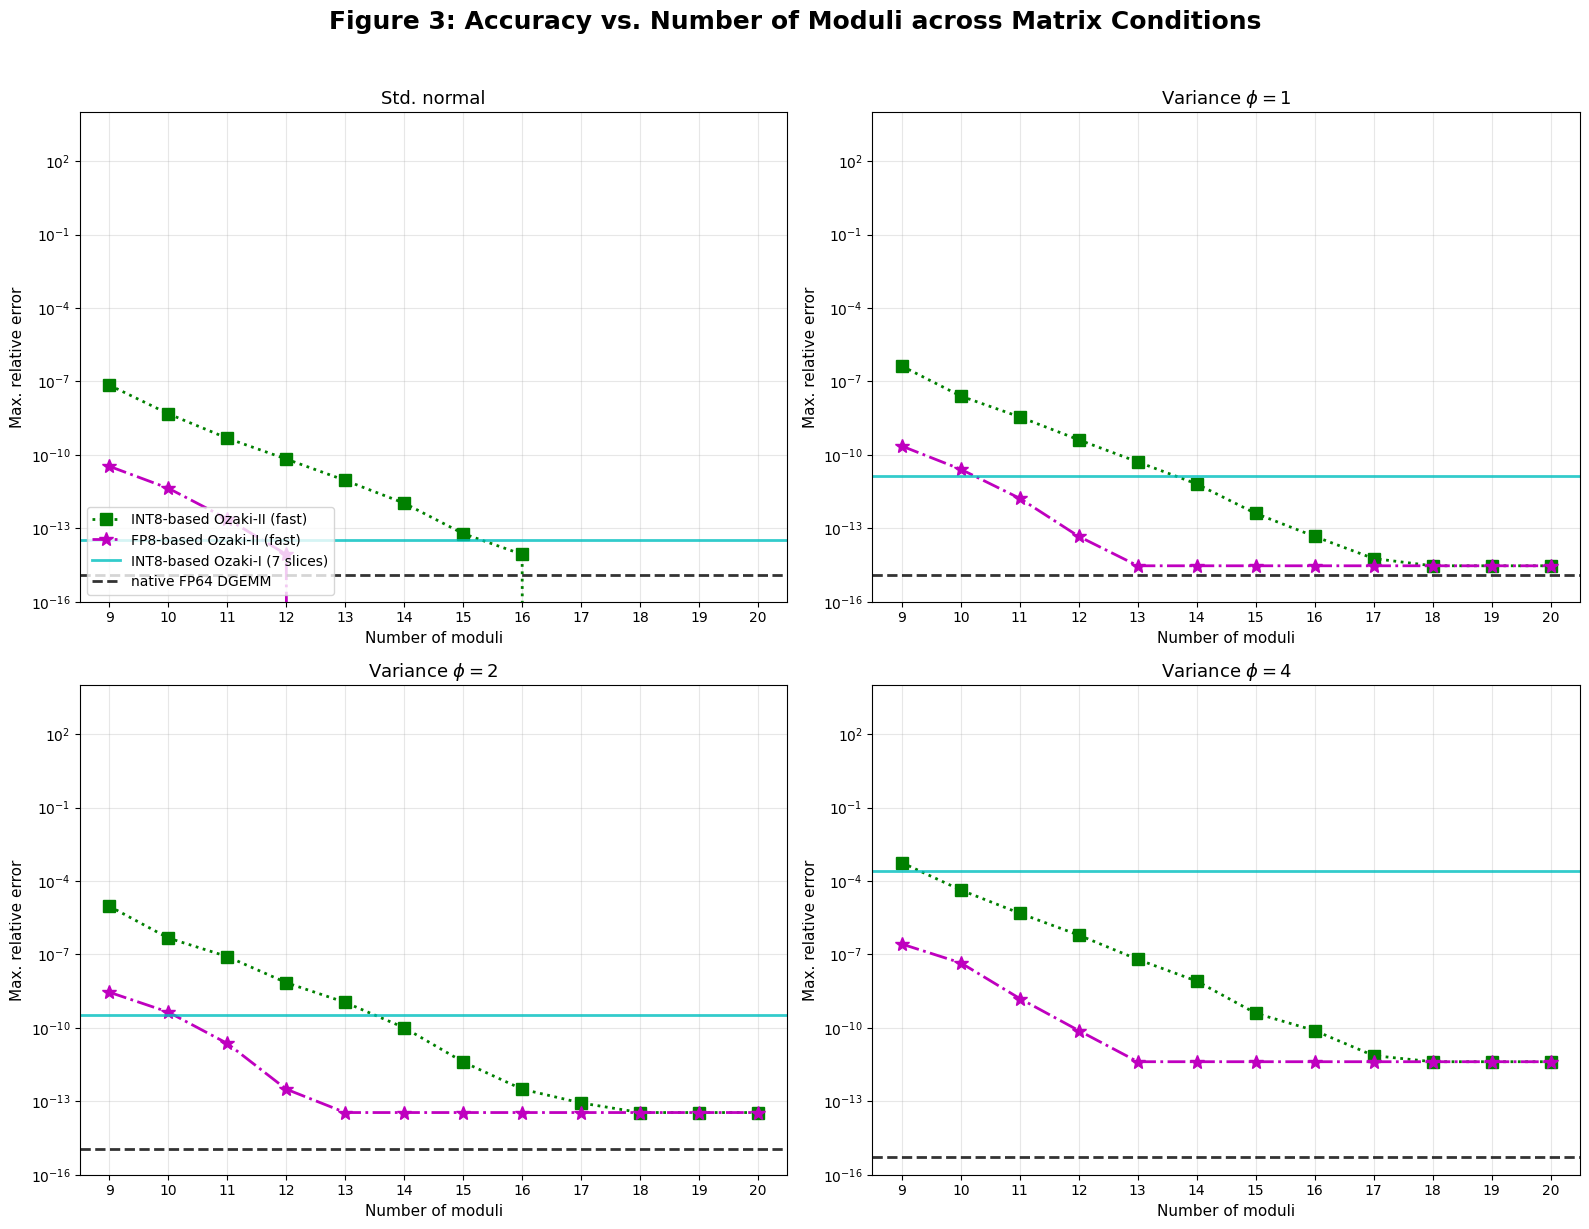

In [27]:
# --- Figure 3 Setup ---
N = 100
repeats = 3
k_range = list(range(9, 21)) 

phi_conditions = [0.0, 1.0, 2.0, 4.0] 
titles = ["Std. normal", "Variance $\phi = 1$", "Variance $\phi = 2$", "Variance $\phi = 4$"]

results = {phi: {'f64': 0, 'o1': 0, 'o2_std': [], 'o2_hyb': []} for phi in phi_conditions}

warnings.filterwarnings('ignore', category=RuntimeWarning)

print("--- Executing Figure 3 Benchmark (Error vs Number of Moduli) ---")

for phi in phi_conditions:
    print(f"Testing Condition: {phi if phi > 0 else 'Std. normal'}...")
    e_f64, e_o1 = 0.0, 0.0
    e_o2_std = [0.0 for _ in k_range]
    e_o2_hyb = [0.0 for _ in k_range]
    
    for r in range(repeats):
        A = utils.random_phi_matrix(N, N, phi, np.float64)
        B = utils.random_phi_matrix(N, N, phi, np.float64)

        perfect = baseline.get_exact_product(A, B, 192)
        
        # 1. Native FP64 Baseline
        e_f64 += average_relative_error(A, B, A @ B, C=perfect)

        # 2. Ozaki-1 INT8 (7 slices)
        res_o1 = o1.full_ozaki_1_fast(A, B, np.int8, 7, np.int32, 7)
        e_o1 += average_relative_error(A, B, res_o1, C=perfect)

        # 3. Ozaki-2 Sweep across k
        for idx, k in enumerate(k_range):
            
            # Standard INT8 (7 hardware bits)
            try:
                moduli_std = o2.get_optimal_moduli(7, k)
                cap_std = sum(np.log2(m) for m in moduli_std)
                target_std = min(53, max(1, int((cap_std - np.log2(N) - 1) / 2.0)))
                
                res_std = o2.full_ozaki_2(A, B, target_std, k, np.int8, np.int32)
                e_o2_std[idx] += average_relative_error(A, B, res_std, C=perfect)
            except Exception:
                e_o2_std[idx] += np.nan

            # Hybrid FP8 (Native ml_dtypes float8_e4m3fn)
            try:
                # We use 8 bits for moduli generation to allow the splits to work within E4M3 bounds
                moduli_hyb = o2.get_hybrid_moduli(k) 
                cap_hyb = sum(np.log2(m) for m in moduli_hyb)
                target_hyb = min(53, max(1, int((cap_hyb - np.log2(N) - 1) / 2.0)))
                
                # TRUE FP8: Compute in float8_e4m3fn, Accumulate in float32
                res_hyb = o2.full_hybrid_ozaki_2(A, B, target_hyb, k, "float8_e4m3fn", np.float32)
                e_o2_hyb[idx] += average_relative_error(A, B, res_hyb, C=perfect)
            except Exception as e:
                e_o2_hyb[idx] += np.nan

    # Average out the repeats
    results[phi]['f64'] = e_f64 / repeats
    results[phi]['o1'] = e_o1 / repeats
    results[phi]['o2_std'] = [e / repeats for e in e_o2_std]
    results[phi]['o2_hyb'] = [e / repeats for e in e_o2_hyb]

warnings.filterwarnings('default', category=RuntimeWarning)

# --- PLOTTING LOGIC (The 2x2 Grid) ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, phi in enumerate(phi_conditions):
    ax = axes[i]
    data = results[phi]
    
    ax.semilogy(k_range, data['o2_std'], 'g:s', linewidth=2, markersize=8, label='INT8-based Ozaki-II (fast)')
    ax.semilogy(k_range, data['o2_hyb'], 'm-.*', linewidth=2, markersize=10, label='FP8-based Ozaki-II (fast)')
    
    ax.axhline(y=data['o1'], color='c', linestyle='-', linewidth=2, alpha=0.8, label='INT8-based Ozaki-I (7 slices)')
    ax.axhline(y=data['f64'], color='k', linestyle='--', linewidth=2, alpha=0.8, label='native FP64 DGEMM')
    
    ax.set_title(titles[i], fontsize=13)
    ax.set_xlabel('Number of moduli', fontsize=11)
    ax.set_ylabel('Max. relative error', fontsize=11)
    
    ax.set_xlim(8.5, 20.5) 
    ax.set_ylim(1e-16, 1e4)
    ax.set_xticks(range(9, 21, 1))
    
    ax.grid(True, which="both", ls="-", alpha=0.3)
    if i == 0: 
        ax.legend(loc='lower left', fontsize=10)

plt.suptitle('Figure 3: Accuracy vs. Number of Moduli across Matrix Conditions', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Running benchmark...
Repeat 1/10
Repeat 2/10
Repeat 3/10
Repeat 4/10
Repeat 5/10
Repeat 6/10
Repeat 7/10
Repeat 8/10
Repeat 9/10
Repeat 10/10


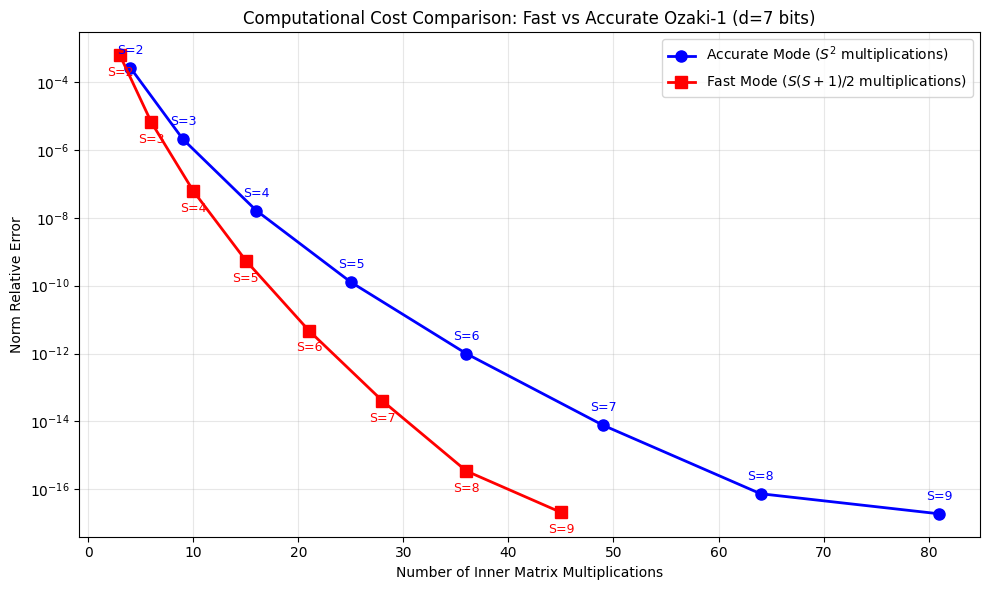

In [ ]:
#crash test : comparaison entre 'fast' (merci Gem pour l'implémentation à l'arrache) et 'accurate' Ozaki-1
import numpy as np
import matplotlib.pyplot as plt
import src.utils as utils
from src.baseline import get_exact_product
from src.err_metrics import forward_error
import src.ozaki_1 as o1

# Assuming full_ozaki_1_fast is added to o1, otherwise you can define it here.
# def full_ozaki_1_fast(A, B, split_type, d, store_type, s): ...

s_range = np.arange(2, 10)

# Calculate the actual number of multiplications for both modes
mults_accurate = [float(s**2) for s in s_range]
mults_fast = [s*(s + 1) / 2 for s in s_range]

errors_accurate = [0.0 for _ in s_range]
errors_fast = [0.0 for _ in s_range]

repeats = 10
N = 100

print("Running benchmark...")
for r in range(repeats):
    print(f"Repeat {r + 1}/{repeats}")
    A = utils.random_mean_var_matrix(N, N, np.float64)
    B = utils.random_mean_var_matrix(N, N, np.float64)
    
    # High precision baseline
    perfect = get_exact_product(A, B, 192)
    
    for i, s in enumerate(s_range):
        # Accurate Mode (the O(s^2) logic currently in your total_trunc function)
        # Note: Depending on your exact imports, you might use o1.multiply_lists_dtype natively here 
        # to ensure it represents the s^2 baseline mathematically if total_trunc filters it out.
        res_acc = o1.full_ozaki_1_trunc(A, B, np.int8, 7, np.int32, s)
        
        # Fast Mode (True fast mode avoiding unecessary operations)
        res_fast = o1.full_ozaki_1_fast(A, B, np.int8, 7, np.int32, s)
        
        errors_accurate[i] += forward_error(A, B, res_acc, C=perfect)
        errors_fast[i] += forward_error(A, B, res_fast, C=perfect)

errors_accurate = [e / repeats for e in errors_accurate]
errors_fast = [e / repeats for e in errors_fast]

# Plotting mimicking the style of the notebook
fig, ax = plt.subplots(figsize=(10, 6))

# Plot accurate vs fast computational bounds
ax.semilogy(mults_accurate, errors_accurate, 'b-o', linewidth=2, markersize=8, label='Accurate Mode ($S^2$ multiplications)')
ax.semilogy(mults_fast, errors_fast, 'r-s', linewidth=2, markersize=8, label='Fast Mode ($S(S+1)/2$ multiplications)')

# Annotate S values for clarity
for i, s in enumerate(s_range):
    ax.annotate(f'S={s}', (mults_accurate[i], errors_accurate[i]), textcoords="offset points", xytext=(0,10), ha='center', color='blue', fontsize=9)
    ax.annotate(f'S={s}', (mults_fast[i], errors_fast[i]), textcoords="offset points", xytext=(0,-15), ha='center', color='red', fontsize=9)

ax.set_xlabel('Number of Inner Matrix Multiplications')
ax.set_ylabel('Norm Relative Error')
ax.set_title('Computational Cost Comparison: Fast vs Accurate Ozaki-1 (d=7 bits)')
ax.grid(True, which="both", ls="-", alpha=0.3)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [29]:
# première batch de commentaires :
# les courbes sont assez parlantes (en partant du principe qu'elles sont justes mdr) :
# on a un gain d'environ 40% en termes de produits matriciels si on utilise la version 'fast' de Ozaki-1
# pour une erreur relative à peine plus élevée : différence constante de 10**(-1) au pire entre les 2 méthodes
# courbe d'erreur probalement écrasée sur la fin du graphe ?

# à suivre : un test avec phi-génération pour vérifier les hypothèses ci-dessus 

In [31]:
# écrasement de la courbe à partir de 9 slices 
# soit le produit est désormais parfaitement exact 
# soit les méthodes ne diffèrent qu'avec un petit nombre de slices

# hem j'ai restart mon kernel et mtn les courbes se chevauchent parfaitement : ça fait zéro sens 
# puisque les courbes du test au-dessus se comportent 'normalement'
# à voir
# c'est corrigé

Running benchmark with random_phi_matrix (phi=3.0)...
Repeat 1/10
Repeat 2/10
Repeat 3/10
Repeat 4/10
Repeat 5/10
Repeat 6/10
Repeat 7/10
Repeat 8/10
Repeat 9/10
Repeat 10/10


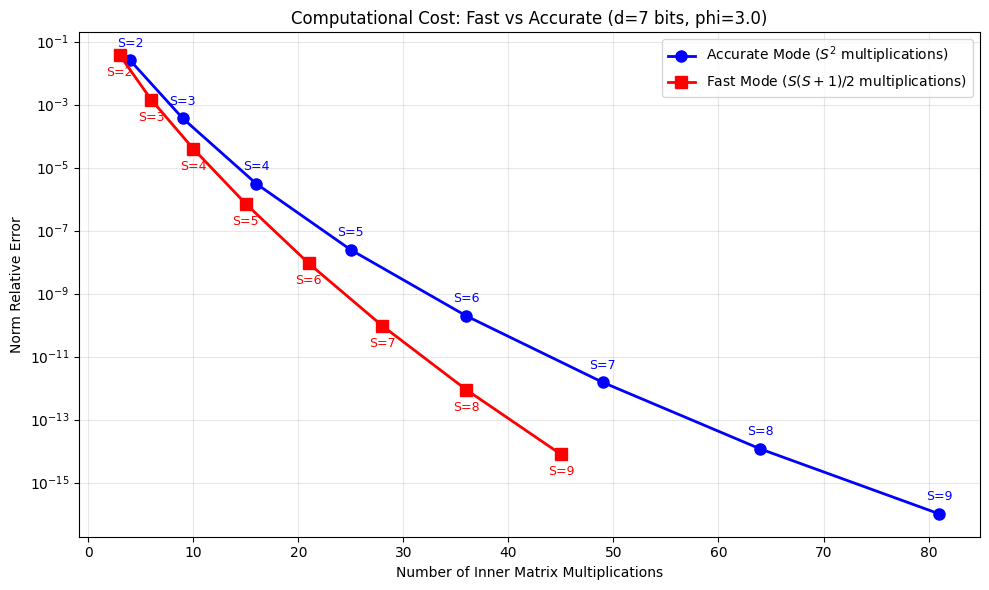

In [3]:
#crash test using phi this time 

import numpy as np
import matplotlib.pyplot as plt
import src.utils as utils
from src.baseline import get_exact_product
from src.err_metrics import forward_error
import src.ozaki_1 as o1

# Assuming full_ozaki_1_fast is in o1, otherwise define it above this cell
# def full_ozaki_1_fast(A, B, split_type, d, store_type, s): ...

s_range = np.arange(2, 10)

# Calculate the actual number of multiplications for both modes
mults_accurate = [float(s**2) for s in s_range]
mults_fast = [s*(s + 1) / 2 for s in s_range]

errors_accurate = [0.0 for _ in s_range]
errors_fast = [0.0 for _ in s_range]

repeats = 10
N = 100
phi = 3.0  # Dynamic range parameter for the matrices

print(f"Running benchmark with random_phi_matrix (phi={phi})...")
for r in range(repeats):
    print(f"Repeat {r + 1}/{repeats}")
    # Generating matrices using phi to simulate dynamic range exponent gaps
    A = utils.random_phi_matrix(N, N, phi, np.float64)
    B = utils.random_phi_matrix(N, N, phi, np.float64)
    
    # High precision baseline
    perfect = get_exact_product(A, B, 192)
    
    for i, s in enumerate(s_range):
        # Accurate Mode (O(S^2))
        res_acc = o1.full_ozaki_1_trunc(A, B, np.int8, 7, np.int32, s)
        
        # Fast Mode (O(S(S+1)/2))
        res_fast = o1.full_ozaki_1_fast(A, B, np.int8, 7, np.int32, s)
        
        errors_accurate[i] += forward_error(A, B, res_acc, C=perfect)
        errors_fast[i] += forward_error(A, B, res_fast, C=perfect)

errors_accurate = [e / repeats for e in errors_accurate]
errors_fast = [e / repeats for e in errors_fast]

# --- PLOTTING ---
fig, ax = plt.subplots(figsize=(10, 6))

# Plot accurate vs fast computational bounds
ax.semilogy(mults_accurate, errors_accurate, 'b-o', linewidth=2, markersize=8, label='Accurate Mode ($S^2$ multiplications)')
ax.semilogy(mults_fast, errors_fast, 'r-s', linewidth=2, markersize=8, label='Fast Mode ($S(S+1)/2$ multiplications)')

# Annotate S values for clarity
for i, s in enumerate(s_range):
    ax.annotate(f'S={s}', (mults_accurate[i], errors_accurate[i]), textcoords="offset points", xytext=(0,10), ha='center', color='blue', fontsize=9)
    ax.annotate(f'S={s}', (mults_fast[i], errors_fast[i]), textcoords="offset points", xytext=(0,-15), ha='center', color='red', fontsize=9)

ax.set_xlabel('Number of Inner Matrix Multiplications')
ax.set_ylabel('Norm Relative Error')
ax.set_title(f'Computational Cost: Fast vs Accurate (d=7 bits, phi={phi})')
ax.grid(True, which="both", ls="-", alpha=0.3)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [33]:
# avec une génération de matrices + disparates, on observe une autre tendance : 
# le nombre de multiplications ne change pas (logique en soi) ; néanmoins, on note une + nette différence au niveau du taux d'erreur
# le taux d'erreurs s'accroît avec le nombre de multiplications : pour la méthode 'accurate', la courbe d'erreur est 'plus' logarithmique 
# que celle de sa consoeur qui est + linéaire

Running benchmark with random_phi_matrix (phi=3.0)...
Repeat 1/3
Repeat 2/3
Repeat 3/3


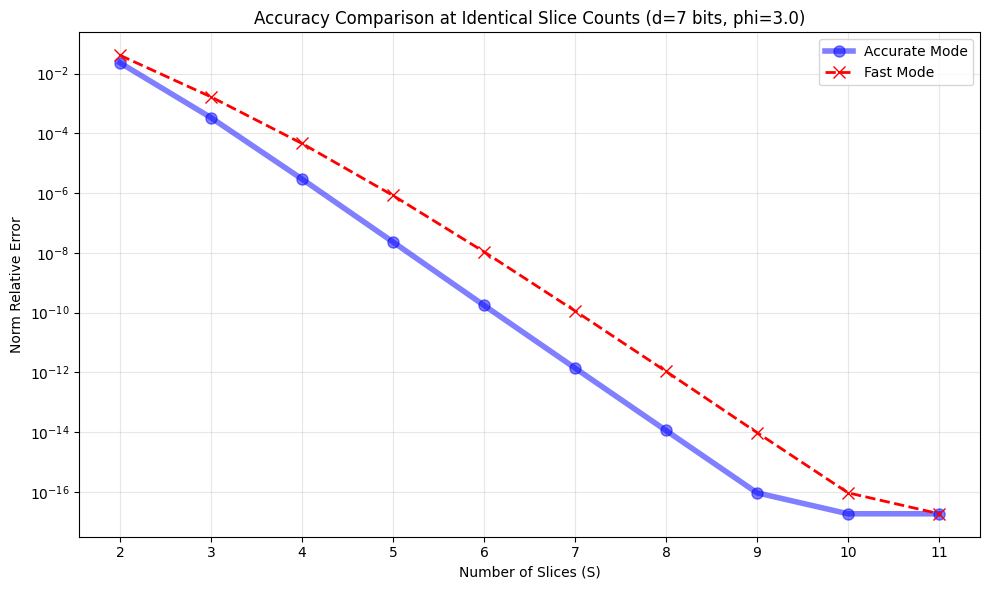

In [ ]:
# test 2 using phi this time

import numpy as np
import matplotlib.pyplot as plt
import src.utils as utils
from src.baseline import get_exact_product
from src.err_metrics import forward_error
import src.ozaki_1 as o1

# Assuming full_ozaki_1_fast is in o1, otherwise define it above this cell
# def full_ozaki_1_fast(A, B, split_type, d, store_type, s): ...

s_range = np.arange(2, 12)

errors_accurate = [0.0 for _ in s_range]
errors_fast = [0.0 for _ in s_range]

repeats = 3
N = 100
phi = 3.0  # Dynamic range parameter for the matrices

print(f"Running benchmark with random_phi_matrix (phi={phi})...")
for r in range(repeats):
    print(f"Repeat {r + 1}/{repeats}")
    # Generating matrices using phi to simulate dynamic range exponent gaps
    A = utils.random_phi_matrix(N, N, phi, np.float64)
    B = utils.random_phi_matrix(N, N, phi, np.float64)
    
    perfect = get_exact_product(A, B, 192)
    
    for i, s in enumerate(s_range):
        res_acc = o1.full_ozaki_1_trunc(A, B, np.int8, 7, np.int32, s)
        res_fast = o1.full_ozaki_1_fast(A, B, np.int8, 7, np.int32, s)
        
        errors_accurate[i] += forward_error(A, B, res_acc, C=perfect)
        errors_fast[i] += forward_error(A, B, res_fast, C=perfect)

errors_accurate = [e / repeats for e in errors_accurate]
errors_fast = [e / repeats for e in errors_fast]

# --- PLOTTING ---
fig, ax = plt.subplots(figsize=(10, 6))

# We use a solid thick line for Accurate, and a dashed line with 'x' for Fast 
# so you can clearly see they perfectly overlap.
ax.semilogy(s_range, errors_accurate, 'b-o', linewidth=4, markersize=8, alpha=0.5, label='Accurate Mode')
ax.semilogy(s_range, errors_fast, 'r--x', linewidth=2, markersize=8, label='Fast Mode')

ax.set_xlabel('Number of Slices (S)')
ax.set_ylabel('Norm Relative Error')
ax.set_title(f'Accuracy Comparison at Identical Slice Counts (d=7 bits, phi={phi})')
ax.set_xticks(s_range)
ax.grid(True, which="both", ls="-", alpha=0.3)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [35]:
# commentaires supp
# pas de palier à 9 slices comme évoqué ci-dessus mais écrasement de la courbe tout simplement
# la courbe est quand même utile pour voir la différence d'erreurs entre les méthodes 
# mais bon, c'était déja visible sur le test précédent

Repeat 1/3
Repeat 2/3
Repeat 3/3


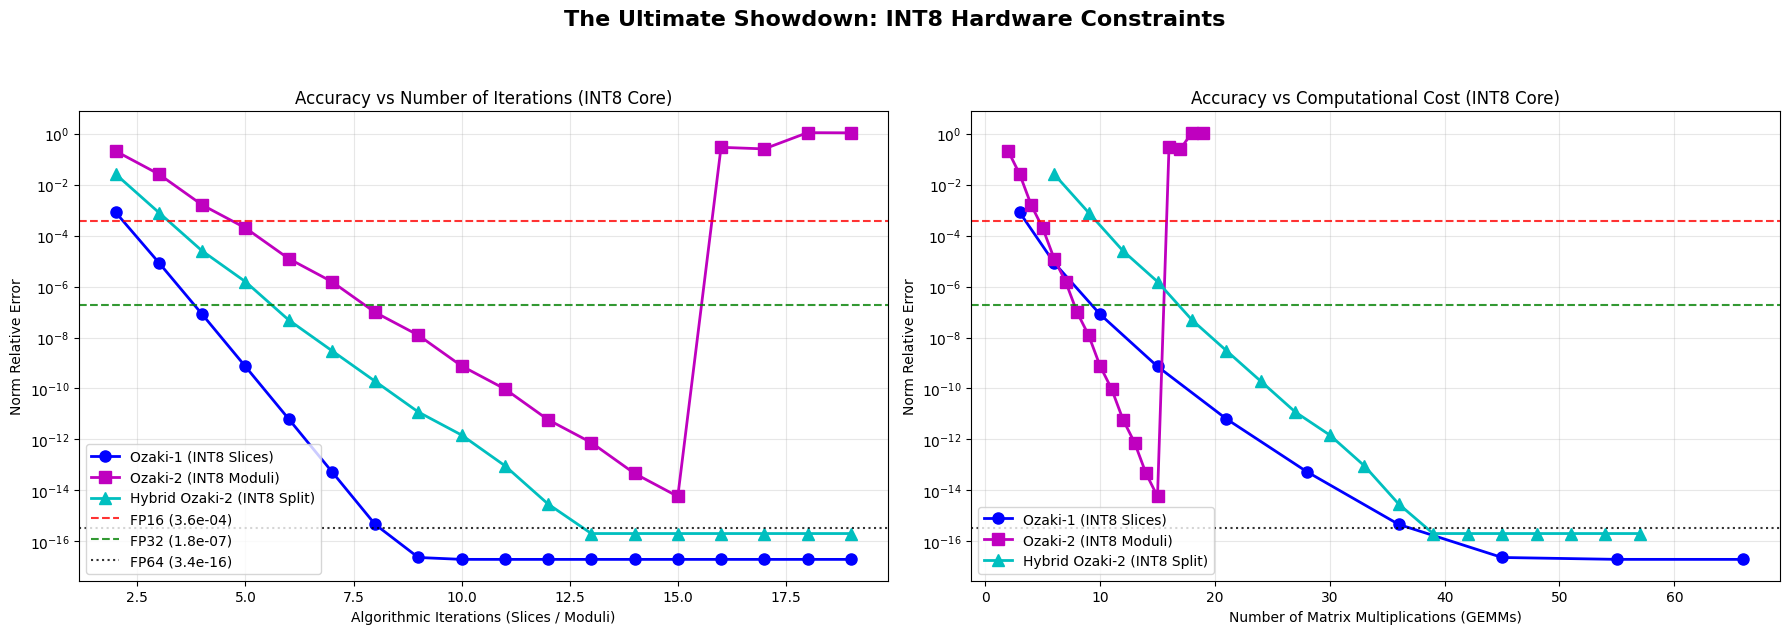

In [2]:
# --- The Ultimate Showdown Benchmark : The INT8 Arena ---

import matplotlib.pyplot as plt
import numpy as np

# Assuming utils, baseline, o1, and o2 are imported

# We need more iterations because INT8 modules carry very little precision per GEMM
i_range = range(2, 20)
N = 100
repeats = 3

error_f16, error_f32, error_f64 = 0.0, 0.0, 0.0
errors_o1 = [0.0 for _ in i_range]
errors_o2 = [0.0 for _ in i_range]
errors_hybrid = [0.0 for _ in i_range] 

for r in range(repeats):
    print(f"Repeat {r + 1}/{repeats}")
    A = utils.random_mean_var_matrix(N, N, np.float64)
    B = utils.random_mean_var_matrix(N, N, np.float64)

    perfect = baseline.get_exact_product(A, B, 192)
    error_f16 += forward_error(A, B, A.astype(np.float16) @ B.astype(np.float16), C=perfect)
    error_f32 += forward_error(A, B, A.astype(np.float32) @ B.astype(np.float32), C=perfect)
    error_f64 += forward_error(A, B, A @ B, C=perfect)

    for (idx, i) in enumerate(i_range):
        # --- 1. Ozaki-1 (INT8 Slices) ---
        # 7 bits effective capacity for INT8 (reserving 1 bit for sign)
        res_o1 = o1.full_ozaki_1_fast(A, B, np.int8, 7, np.int32, i)
        errors_o1[idx] += forward_error(A, B, res_o1, C=perfect)

        # --- 2. Ozaki-2 (INT8 Moduli) ---
        # Capacity = i * 7 bits. Required = log2(N) + 2*target_bits + 1
        max_target_bits_o2 = int((i * 7.0 - np.log2(N) - 1) / 2.0)
        max_target_bits_o2 = max(1, max_target_bits_o2)
        
        res_o2 = o2.full_ozaki_2(A, B, max_target_bits_o2, i, np.int8, np.int32)
        errors_o2[idx] += forward_error(A, B, res_o2, C=perfect)

        # --- 3. Hybrid Ozaki-2 (INT8 Compute -> INT32 Store) ---
        # Hardware capacity per modulus is now ~14 bits (2x INT8 capacity).
        max_target_bits_hybrid = int((i * 14.0 - np.log2(N) - 1) / 2.0)
        
        # Plafond de 53 bits toujours en place (mur du float64)
        moduli = o2.get_hybrid_moduli(i)
        P = math.prod(moduli)
        actual_capacity_bits = math.log2(P)

        # Now target bits fits perfectly inside the true CRT capacity
        max_target_bits_hybrid = int((actual_capacity_bits - np.log2(N) - 1) / 2.0)
        max_target_bits_hybrid = min(53, max(1, max_target_bits_hybrid))
        
        # We pass np.int8 for computation ! The true test.
        res_hybrid = o2.full_hybrid_ozaki_2(A, B, max_target_bits_hybrid, min(53, i), np.int8, np.int32)
        errors_hybrid[idx] += forward_error(A, B, res_hybrid, C=perfect)

error_f16 /= repeats
error_f32 /= repeats
error_f64 /= repeats
errors_o1 = [a / repeats for a in errors_o1]
errors_o2 = [a / repeats for a in errors_o2]
errors_hybrid = [a / repeats for a in errors_hybrid]

# --- PLOTTING LOGIC ---

# Computational cost (GEMMs)
mults_o1 = [s * (s + 1) / 2 for s in i_range] 
mults_o2 = [k for k in i_range]               
mults_hybrid = [3 * k for k in i_range]       

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Relative Error vs Iterations (Slices/Moduli)
ax1.semilogy(i_range, errors_o1, 'b-o', linewidth=2, markersize=8, label='Ozaki-1 (INT8 Slices)')
ax1.semilogy(i_range, errors_o2, 'm-s', linewidth=2, markersize=8, label='Ozaki-2 (INT8 Moduli)')
ax1.semilogy(i_range, errors_hybrid, 'c-^', linewidth=2, markersize=8, label='Hybrid Ozaki-2 (INT8 Split)')

ax1.axhline(y=error_f16, color='red', linestyle='--', alpha=0.8, label=f'FP16 ({error_f16:.1e})')
ax1.axhline(y=error_f32, color='green', linestyle='--', alpha=0.8, label=f'FP32 ({error_f32:.1e})')
ax1.axhline(y=error_f64, color='black', linestyle=':', alpha=0.8, label=f'FP64 ({error_f64:.1e})')

ax1.set_xlabel('Algorithmic Iterations (Slices / Moduli)')
ax1.set_ylabel('Norm Relative Error')
ax1.set_title('Accuracy vs Number of Iterations (INT8 Core)')
ax1.grid(True, which="both", ls="-", alpha=0.3)
ax1.legend(loc='lower left')

# Plot 2: Relative Error vs Computational Cost (GEMMs)
ax2.semilogy(mults_o1[:10], errors_o1[:10], 'b-o', linewidth=2, markersize=8, label='Ozaki-1 (INT8 Slices)') # Truncated to avoid stretching X axis
ax2.semilogy(mults_o2, errors_o2, 'm-s', linewidth=2, markersize=8, label='Ozaki-2 (INT8 Moduli)')
ax2.semilogy(mults_hybrid, errors_hybrid, 'c-^', linewidth=2, markersize=8, label='Hybrid Ozaki-2 (INT8 Split)')

ax2.axhline(y=error_f16, color='red', linestyle='--', alpha=0.8)
ax2.axhline(y=error_f32, color='green', linestyle='--', alpha=0.8)
ax2.axhline(y=error_f64, color='black', linestyle=':', alpha=0.8)

ax2.set_xlabel('Number of Matrix Multiplications (GEMMs)')
ax2.set_ylabel('Norm Relative Error')
ax2.set_title('Accuracy vs Computational Cost (INT8 Core)')
ax2.grid(True, which="both", ls="-", alpha=0.3)
ax2.legend(loc='lower left')

plt.suptitle('The Ultimate Showdown: INT8 Hardware Constraints', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

Repeat 1/3
Repeat 2/3
Repeat 3/3


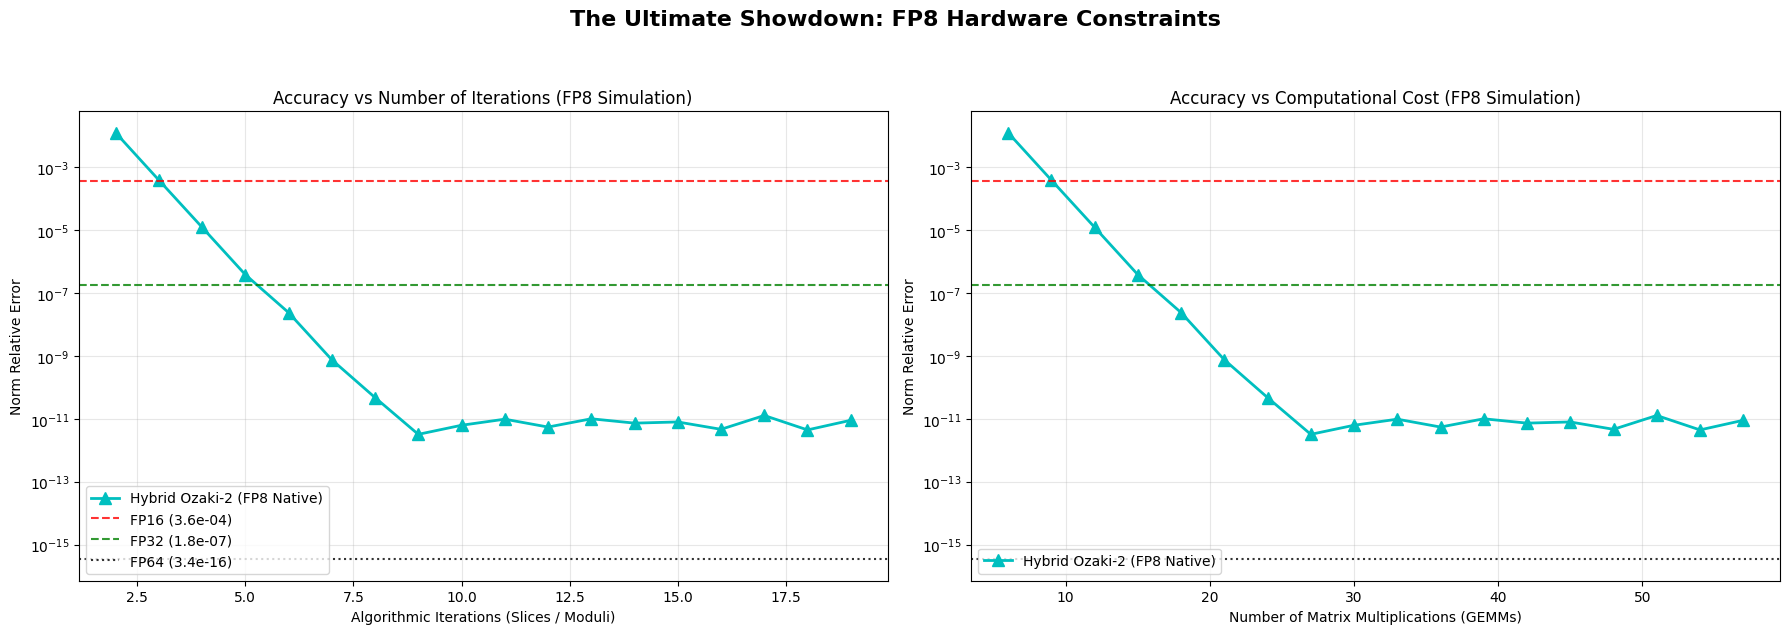

In [5]:
# Assuming utils, baseline, o1, and o2 are imported

i_range = range(2, 20)
N = 100
repeats = 3

error_f16, error_f32, error_f64 = 0.0, 0.0, 0.0
errors_hybrid = [0.0 for _ in i_range] 

for r in range(repeats):
    print(f"Repeat {r + 1}/{repeats}")
    A = utils.random_mean_var_matrix(N, N, np.float64)
    B = utils.random_mean_var_matrix(N, N, np.float64)

    perfect = baseline.get_exact_product(A, B, 192)
    error_f16 += forward_error(A, B, A.astype(np.float16) @ B.astype(np.float16), C=perfect)
    error_f32 += forward_error(A, B, A.astype(np.float32) @ B.astype(np.float32), C=perfect)
    error_f64 += forward_error(A, B, A @ B, C=perfect)

    for (idx, i) in enumerate(i_range):
        # --- 3. Hybrid Ozaki-2 (FP8 Split) ---
        # The hybrid method handles FP8 natively via Karatsuba/Square splitting.
        moduli_hybrid = o2h.get_hybrid_moduli(i)
        actual_capacity_bits_hybrid = math.log2(math.prod(moduli_hybrid))

        # Dynamic target sizing
        max_target_bits_hybrid = int((actual_capacity_bits_hybrid - np.log2(N) - 1) / 2.0)
        max_target_bits_hybrid = min(53, max(1, max_target_bits_hybrid))
        
        # We pass float16 as a vessel, but the math restricts bounds to FP8
        res_hybrid = o2h.full_hybrid_ozaki_2_acc(A, B, 53, i, "float8_e4m3", np.float32)
        errors_hybrid[idx] += forward_error(A, B, res_hybrid, C=perfect)

error_f16 /= repeats
error_f32 /= repeats
error_f64 /= repeats
errors_hybrid = [a / repeats for a in errors_hybrid]

# --- PLOTTING LOGIC ---

# Computational cost (GEMMs)
mults_o1 = [s * (s + 1) / 2 for s in i_range] 
mults_o2 = [k for k in i_range]               
mults_hybrid = [3 * k for k in i_range]       

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Relative Error vs Iterations (Slices/Moduli)
ax1.semilogy(i_range, errors_hybrid, 'c-^', linewidth=2, markersize=8, label='Hybrid Ozaki-2 (FP8 Native)')

ax1.axhline(y=error_f16, color='red', linestyle='--', alpha=0.8, label=f'FP16 ({error_f16:.1e})')
ax1.axhline(y=error_f32, color='green', linestyle='--', alpha=0.8, label=f'FP32 ({error_f32:.1e})')
ax1.axhline(y=error_f64, color='black', linestyle=':', alpha=0.8, label=f'FP64 ({error_f64:.1e})')

ax1.set_xlabel('Algorithmic Iterations (Slices / Moduli)')
ax1.set_ylabel('Norm Relative Error')
ax1.set_title('Accuracy vs Number of Iterations (FP8 Simulation)')
ax1.grid(True, which="both", ls="-", alpha=0.3)
ax1.legend(loc='lower left')

# Plot 2: Relative Error vs Computational Cost (GEMMs)
ax2.semilogy(mults_hybrid, errors_hybrid, 'c-^', linewidth=2, markersize=8, label='Hybrid Ozaki-2 (FP8 Native)')

ax2.axhline(y=error_f16, color='red', linestyle='--', alpha=0.8)
ax2.axhline(y=error_f32, color='green', linestyle='--', alpha=0.8)
ax2.axhline(y=error_f64, color='black', linestyle=':', alpha=0.8)

ax2.set_xlabel('Number of Matrix Multiplications (GEMMs)')
ax2.set_ylabel('Norm Relative Error')
ax2.set_title('Accuracy vs Computational Cost (FP8 Simulation)')
ax2.grid(True, which="both", ls="-", alpha=0.3)
ax2.legend(loc='lower left')

plt.suptitle('The Ultimate Showdown: FP8 Hardware Constraints', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

<>:91: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:91: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
/tmp/ipykernel_49801/605021521.py:91: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  plt.suptitle('Fast Mode vs Accurate Mode (High Variance $\phi=4$)', fontsize=16, fontweight='bold', y=1.05)


Repeat 1/3
Repeat 2/3
Repeat 3/3


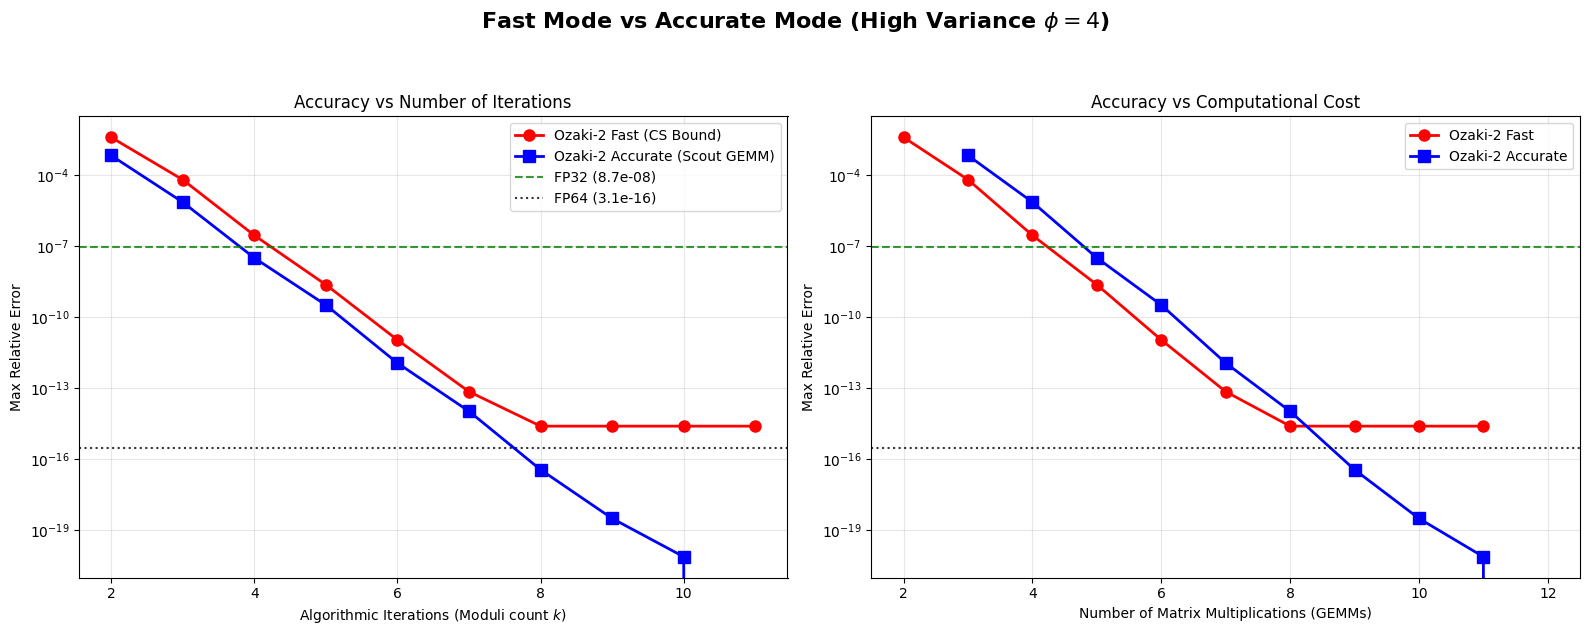

In [3]:
# --- The Fast vs Accurate Benchmark ---
i_range = range(2, 12)
N = 100
repeats = 3

error_f16, error_f32, error_f64 = 0.0, 0.0, 0.0
errors_fast = [0.0 for _ in i_range]
errors_acc = [0.0 for _ in i_range]

warnings.filterwarnings('ignore', category=RuntimeWarning)

for r in range(repeats):
    print(f"Repeat {r + 1}/{repeats}")
    # We MUST use high variance, otherwise Fast Mode bounds are "close enough"
    A = utils.random_phi_matrix(N, N, 4.0, np.float64)
    B = utils.random_phi_matrix(N, N, 4.0, np.float64)

    perfect = baseline.get_exact_product(A, B, 192)
    error_f16 += forward_error(A, B, A.astype(np.float16) @ B.astype(np.float16), C=perfect)
    error_f32 += forward_error(A, B, A.astype(np.float32) @ B.astype(np.float32), C=perfect)
    error_f64 += forward_error(A, B, A @ B, C=perfect)

    for (idx, i) in enumerate(i_range):
        target_fast = 53
        try:
            # 1. Ozaki-2 FAST MODE
            moduli = o2.get_optimal_moduli(15, i)
            # FIX: Use math.log2 here too, as m is a standard Python int
            capacity = sum(math.log2(m) for m in moduli) 
            target_fast = min(53, max(1, int((capacity - np.log2(N) - 1) / 2.0)))
            
            res_fast = o2.full_ozaki_2(A, B, target_fast, i, np.int16, np.int64)
            errors_fast[idx] += forward_error(A, B, res_fast, C=perfect)
        except Exception:
            errors_fast[idx] += np.nan

        try:
            # 2. Ozaki-2 ACCURATE MODE (Scout GEMM Bounding)
            # Depending on how you implemented it, accurate mode might calculate its own target bounds
            # natively inside the function using the scout GEMM. We pass the same parameters for parity.
            res_acc = o2.full_ozaki_2_acc(A, B, target_fast, i, np.int16, np.int64)
            errors_acc[idx] += forward_error(A, B, res_acc, C=perfect)
        except Exception as e:
            print(e)
            errors_acc[idx] += np.nan

error_f16 /= repeats
error_f32 /= repeats
error_f64 /= repeats
errors_fast = [a / repeats for a in errors_fast]
errors_acc = [a / repeats for a in errors_acc]

warnings.filterwarnings('default', category=RuntimeWarning)

# --- PLOTTING LOGIC ---

# Computational cost (GEMMs)
mults_fast = [k for k in i_range]       # Fast: 1 GEMM per modulus
mults_acc = [k + 1 for k in i_range]    # Accurate: 1 GEMM per modulus + 1 Scout GEMM

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Relative Error vs Iterations (Moduli Count)
ax1.semilogy(i_range, errors_fast, 'r-o', linewidth=2, markersize=8, label='Ozaki-2 Fast (CS Bound)')
ax1.semilogy(i_range, errors_acc, 'b-s', linewidth=2, markersize=8, label='Ozaki-2 Accurate (Scout GEMM)')

ax1.axhline(y=error_f32, color='green', linestyle='--', alpha=0.8, label=f'FP32 ({error_f32:.1e})')
ax1.axhline(y=error_f64, color='black', linestyle=':', alpha=0.8, label=f'FP64 ({error_f64:.1e})')

ax1.set_xlabel('Algorithmic Iterations (Moduli count $k$)')
ax1.set_ylabel('Max Relative Error')
ax1.set_title('Accuracy vs Number of Iterations')
ax1.grid(True, which="both", ls="-", alpha=0.3)
ax1.legend(loc='upper right')

# Plot 2: Relative Error vs Computational Cost (GEMMs)
ax2.semilogy(mults_fast, errors_fast, 'r-o', linewidth=2, markersize=8, label='Ozaki-2 Fast')
# Notice we plot against mults_acc here, shifting the blue line to the right!
ax2.semilogy(mults_acc, errors_acc, 'b-s', linewidth=2, markersize=8, label='Ozaki-2 Accurate')

ax2.axhline(y=error_f32, color='green', linestyle='--', alpha=0.8)
ax2.axhline(y=error_f64, color='black', linestyle=':', alpha=0.8)

ax2.set_xlabel('Number of Matrix Multiplications (GEMMs)')
ax2.set_ylabel('Max Relative Error')
ax2.set_title('Accuracy vs Computational Cost')

ax2.grid(True, which="both", ls="-", alpha=0.3)
ax2.legend(loc='upper right')

plt.suptitle('Fast Mode vs Accurate Mode (High Variance $\phi=4$)', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

<>:106: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:106: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
/tmp/ipykernel_41960/2583534025.py:106: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  ax.set_title(f'Variance $\phi = {int(phi)}$', fontsize=14, fontweight='bold')


--- Executing The Ultimate Ozaki-II Matrix Arena ---

Processing Variance Condition: phi = 0.0

Processing Variance Condition: phi = 1.0

Processing Variance Condition: phi = 2.0

Processing Variance Condition: phi = 4.0


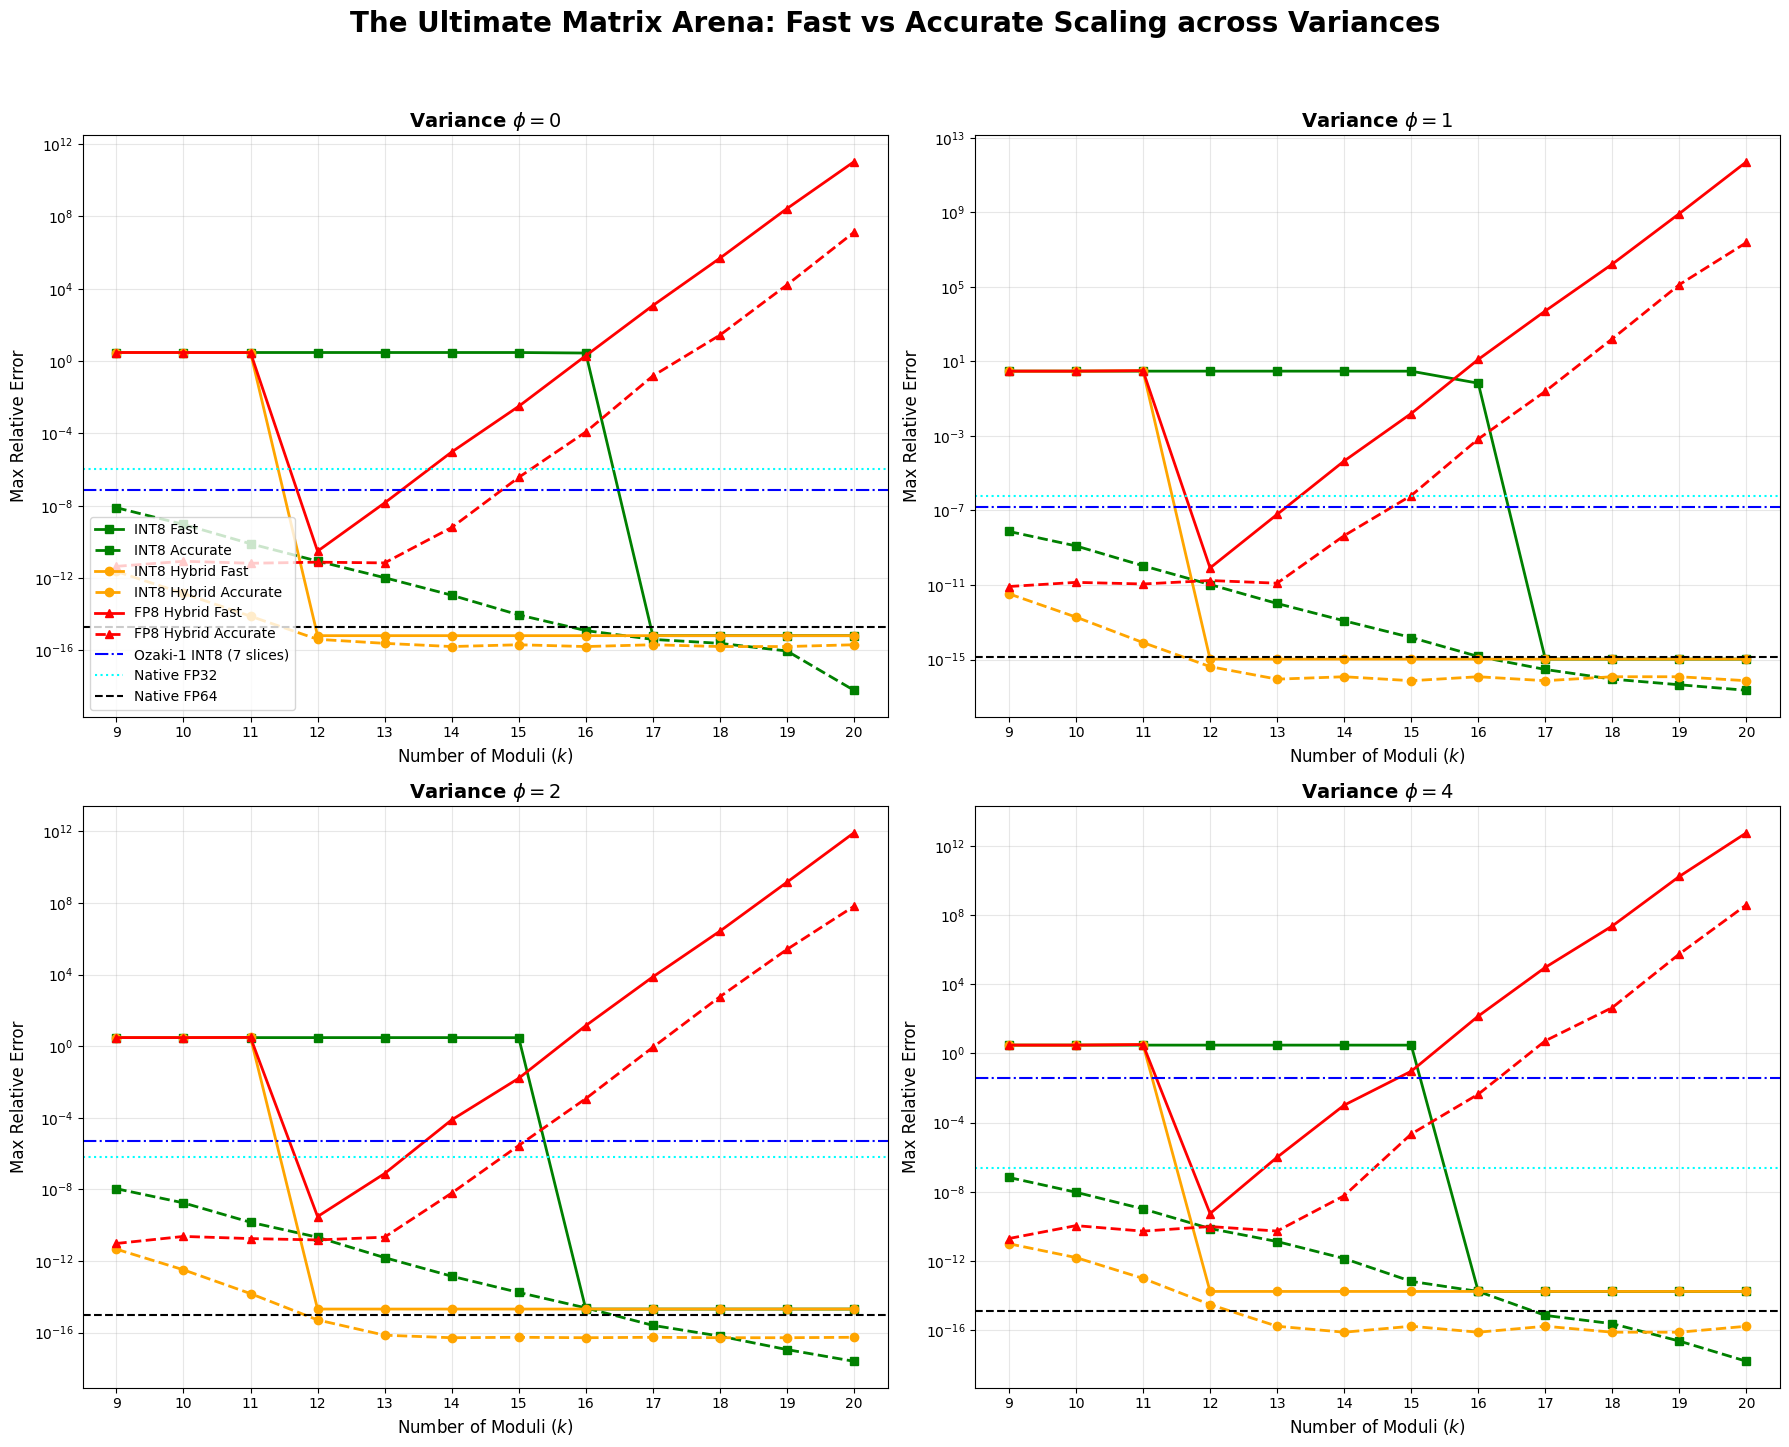

In [3]:
# --- The Ultimate Figure 3 Benchmark Setup ---
N = 100
repeats = 3
k_range = list(range(9, 21)) 
phi_conditions = [0.0, 1.0, 2.0, 4.0] 

results = {phi: {
    'f32': 0, 'f64': 0, 'o1': 0, 
    'o2_int8_fast': [0.0]*len(k_range), 'o2_int8_acc': [0.0]*len(k_range),
    'o2_fp8_fast': [0.0]*len(k_range), 'o2_fp8_acc': [0.0]*len(k_range),
    'o2_int8_hyb_fast': [0.0]*len(k_range), 'o2_int8_hyb_acc': [0.0]*len(k_range),
    'o2_fp8_hyb_fast': [0.0]*len(k_range), 'o2_fp8_hyb_acc': [0.0]*len(k_range)
} for phi in phi_conditions}

warnings.filterwarnings('ignore', category=RuntimeWarning)
print("--- Executing The Ultimate Ozaki-II Matrix Arena ---")

for phi in phi_conditions:
    print(f"\nProcessing Variance Condition: phi = {phi}")
    
    for r in range(repeats):

        A = utils.random_phi_matrix(N,N, phi, np.float64)
        B = utils.random_phi_matrix(N,N, phi, np.float64)
        if phi == 0.0:
            A = utils.random_mean_var_matrix(N, N, np.float64)
            B = utils.random_mean_var_matrix(N, N, np.float64)
        perfect = baseline.get_exact_product(A, B, 256)
        
        # Baselines
        results[phi]['f32'] += max_norm_relative_error(A, B, A.astype(np.float32) @ B.astype(np.float32), C=perfect)
        results[phi]['f64'] += max_norm_relative_error(A, B, A @ B, C=perfect)
        
        # Ozaki-1 INT8 (7 slices)
        res_o1 = o1.full_ozaki_1_fast(A, B, np.int8, 7, np.int32, 7)
        results[phi]['o1'] += max_relative_error(A, B, res_o1, C=perfect)
        for idx, k in enumerate(k_range):
            # 1. INT8 FAST MODE
            target_std = 53
            try:
                res_int8_fast = o2.full_ozaki_2(A, B, target_std, k, np.int8, np.int32)
                results[phi]['o2_int8_fast'][idx] += max_norm_relative_error(A, B, res_int8_fast, C=perfect)
            except Exception as e:
                results[phi]['o2_int8_fast'][idx] += np.nan

            # 2. INT8 ACCURATE MODE
            try:
                res_i8_acc = o2.full_ozaki_2_acc(A, B, target_std, k, np.int8, np.int32)
                results[phi]['o2_int8_acc'][idx] += max_norm_relative_error(A, B, res_i8_acc, C=perfect)
            except Exception as e:
                results[phi]['o2_int8_acc'][idx] += np.nan

            # 3. INT8 HYBRID FAST MODE
            try:
                res_int8_hyb_fast = o2h.full_hybrid_ozaki_2(A, B, target_std, k, np.int8, np.int32)
                results[phi]['o2_int8_hyb_fast'][idx] += max_norm_relative_error(A, B, res_int8_hyb_fast, C=perfect)
            except Exception as e:
                results[phi]['o2_int8_hyb_fast'][idx] += np.nan

            # 4. INT8 HYBRID ACCURATE MODE
            try:
                res_int8_hyb_acc = o2h.full_hybrid_ozaki_2_acc(A, B, target_std, k, np.int8, np.int32)
                results[phi]['o2_int8_hyb_acc'][idx] += max_norm_relative_error(A, B, res_int8_hyb_acc, C=perfect)
            except Exception as e:
                results[phi]['o2_int8_hyb_acc'][idx] += np.nan

            # 5. FP8 HYBRID FAST MODE
            try:
                res_fp8_hyb_fast = o2h.full_hybrid_ozaki_2(A, B, target_std, k, ml_dtypes.float8_e4m3fn, np.float32)
                results[phi]['o2_fp8_hyb_fast'][idx] += max_norm_relative_error(A, B, res_fp8_hyb_fast, C=perfect)
            except Exception as e:
                results[phi]['o2_fp8_hyb_fast'][idx] += np.nan
                
            # 6. FP8 HYBRID ACCURATE MODE
            try:
                res_fp8_hyb_acc = o2h.full_hybrid_ozaki_2_acc(A, B, target_std, k, ml_dtypes.float8_e4m3fn, np.float32)
                results[phi]['o2_fp8_hyb_acc'][idx] += max_norm_relative_error(A, B, res_fp8_hyb_acc, C=perfect)
            except Exception as e:
                results[phi]['o2_fp8_hyb_acc'][idx] += np.nan

# --- UPDATED PLOTTING LOGIC (The 2x2 Grid) ---
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for i, phi in enumerate(phi_conditions):
    ax = axes[i]
    d = results[phi]
    
    # Standard Curves
    ax.semilogy(k_range, d['o2_int8_fast'], color='green', marker='s', linestyle='-', linewidth=2, label='INT8 Fast')
    ax.semilogy(k_range, d['o2_int8_acc'], color='green', marker='s', linestyle='--', linewidth=2, label='INT8 Accurate')
    
    # Hybrid INT8 Curves
    ax.semilogy(k_range, d['o2_int8_hyb_fast'], color='orange', marker='o', linestyle='-', linewidth=2, label='INT8 Hybrid Fast')
    ax.semilogy(k_range, d['o2_int8_hyb_acc'], color='orange', marker='o', linestyle='--', linewidth=2, label='INT8 Hybrid Accurate')

    # Hybrid FP8 Curves
    ax.semilogy(k_range, d['o2_fp8_hyb_fast'], color='red', marker='^', linestyle='-', linewidth=2, label='FP8 Hybrid Fast')
    ax.semilogy(k_range, d['o2_fp8_hyb_acc'], color='red', marker='^', linestyle='--', linewidth=2, label='FP8 Hybrid Accurate')
    
    # Baselines
    ax.axhline(y=d['o1'], color='blue', linestyle='-.', label='Ozaki-1 INT8 (7 slices)')
    ax.axhline(y=d['f32'], color='cyan', linestyle=':', label='Native FP32')
    ax.axhline(y=d['f64'], color='black', linestyle='--', label='Native FP64')
    
    ax.set_title(f'Variance $\phi = {int(phi)}$', fontsize=14, fontweight='bold')
    ax.set_xlabel('Number of Moduli ($k$)', fontsize=12)
    ax.set_ylabel('Max Relative Error', fontsize=12)
    ax.set_xlim(8.5, 20.5) 
    ax.set_xticks(range(9, 21, 1))
    ax.grid(True, which="both", ls="-", alpha=0.3)
    if i == 0: 
        ax.legend(loc='lower left', fontsize=10)

plt.suptitle('The Ultimate Matrix Arena: Fast vs Accurate Scaling across Variances', fontsize=20, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

<>:97: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:110: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:97: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:110: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
/tmp/ipykernel_59511/162885424.py:97: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  ax1.set_title(f'Accuracy vs $\phi$ (Fixed Slices $s={fixed_s}$)')
/tmp/ipykernel_59511/162885424.py:110: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the fut

Running Experiment 1: Accuracy vs Phi...
8.0Computing FP32/FP64 baselines for fixed Phi...
Running Experiment 2: Accuracy vs Number of Slices...
11

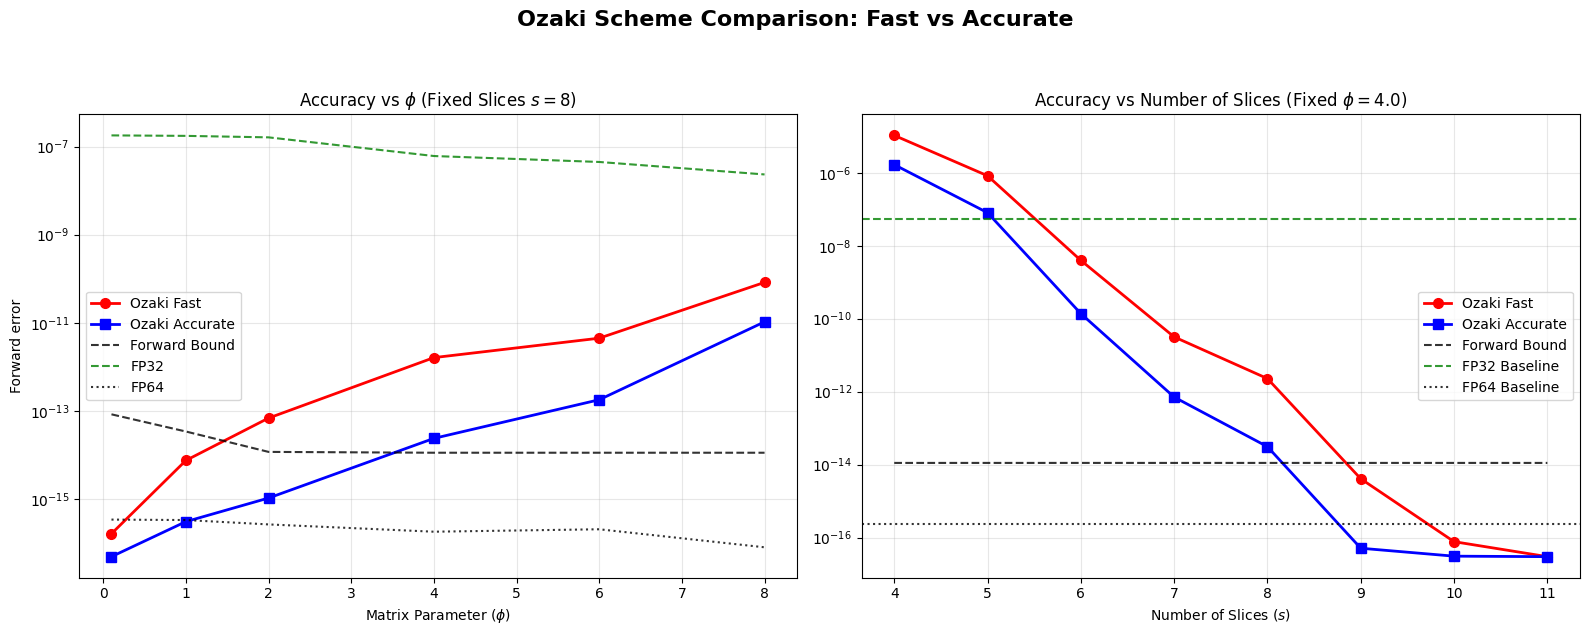

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# --- PARAMETERS ---
N = 100
repeats = 5

phi_range = [0.1, 1.0, 2.0, 4.0, 6.0, 8.0]
s_range = range(4, 12)

fixed_s = 8
fixed_phi = 4.0

# --- EXPERIMENT 1: Varying Phi (Fixed s) ---
errors_fast_phi = []
errors_acc_phi = []
bounds_phi = []
errors_f32_phi = []
errors_f64_phi = []

print("Running Experiment 1: Accuracy vs Phi...")
for phi in phi_range:
    print(f"\r{phi}", end="")
    err_fast, err_acc, bound, err_f32, err_f64 = 0.0, 0.0, 0.0, 0.0, 0.0
    for _ in range(repeats):
        A = utils.random_phi_matrix(N, N, phi, dtype=np.float64)
        B = utils.random_phi_matrix(N, N, phi, dtype=np.float64)
        perfect = baseline.get_exact_product(A, B, 192)

        res_fast = o1.full_ozaki_1_fast(A, B, np.int8, 7, np.int32, fixed_s)
        res_acc = o1.full_ozaki_1_trunc(A, B, np.int8, 7, np.int32, fixed_s)

        err_fast += forward_error(A, B, res_fast, C=perfect)
        err_acc += forward_error(A, B, res_acc, C=perfect)
        bound += forward_bound(A, B)
        
        err_f32 += forward_error(A, B, A.astype(np.float32) @ B.astype(np.float32), C=perfect)
        err_f64 += forward_error(A, B, A @ B, C=perfect)
        
    errors_fast_phi.append(err_fast / repeats)
    errors_acc_phi.append(err_acc / repeats)
    bounds_phi.append(bound / repeats)
    errors_f32_phi.append(err_f32 / repeats)
    errors_f64_phi.append(err_f64 / repeats)

# --- BASELINE FOR EXPERIMENT 2 ---
# Compute the FP32/FP64 baselines once for the fixed_phi used in Experiment 2
print("\nComputing FP32/FP64 baselines for fixed Phi...")
baseline_f32_s, baseline_f64_s = 0.0, 0.0
for _ in range(repeats):
    A = utils.random_phi_matrix(N, N, fixed_phi, dtype=np.float64)
    B = utils.random_phi_matrix(N, N, fixed_phi, dtype=np.float64)
    perfect = baseline.get_exact_product(A, B, 192)
    baseline_f32_s += forward_error(A, B, A.astype(np.float32) @ B.astype(np.float32), C=perfect)
    baseline_f64_s += forward_error(A, B, A @ B, C=perfect)

baseline_f32_s /= repeats
baseline_f64_s /= repeats

# --- EXPERIMENT 2: Varying Slices (Fixed Phi) ---
errors_fast_s = []
errors_acc_s = []
bounds_s = []

print("\nRunning Experiment 2: Accuracy vs Number of Slices...")
for s in s_range:
    print(f"\r{s}", end="")
    err_fast, err_acc, bound = 0.0, 0.0, 0.0
    for _ in range(repeats):
        A = utils.random_phi_matrix(N, N, fixed_phi, dtype=np.float64)
        B = utils.random_phi_matrix(N, N, fixed_phi, dtype=np.float64)
        perfect = baseline.get_exact_product(A, B, 192)

        res_fast = o1.full_ozaki_1_fast(A, B, np.int8, 7, np.int32, s)
        res_acc = o1.full_ozaki_1_trunc(A, B, np.int8, 7, np.int32, s)

        err_fast += forward_error(A, B, res_fast, C=perfect)
        err_acc += forward_error(A, B, res_acc, C=perfect)
        bound += forward_bound(A, B)
        
    errors_fast_s.append(err_fast / repeats)
    errors_acc_s.append(err_acc / repeats)
    bounds_s.append(bound / repeats)

# --- PLOTTING LOGIC ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Error vs Phi (Left)
ax1.semilogy(phi_range, errors_fast_phi, 'r-o', linewidth=2, markersize=7, label='Ozaki Fast')
ax1.semilogy(phi_range, errors_acc_phi, 'b-s', linewidth=2, markersize=7, label='Ozaki Accurate')
ax1.semilogy(phi_range, bounds_phi, 'k--', linewidth=1.5, alpha=0.8, label='Forward Bound')
ax1.semilogy(phi_range, errors_f32_phi, color='green', linestyle='--', linewidth=1.5, alpha=0.8, label='FP32')
ax1.semilogy(phi_range, errors_f64_phi, color='black', linestyle=':', linewidth=1.5, alpha=0.8, label='FP64')

ax1.set_xlabel(r'Matrix Parameter ($\phi$)')
ax1.set_ylabel('Forward error')
ax1.set_title(f'Accuracy vs $\phi$ (Fixed Slices $s={fixed_s}$)')
ax1.grid(True, which="both", ls="-", alpha=0.3)
ax1.legend(loc='best')

# Plot 2: Error vs Slices (Right)
ax2.semilogy(s_range, errors_fast_s, 'r-o', linewidth=2, markersize=7, label='Ozaki Fast')
ax2.semilogy(s_range, errors_acc_s, 'b-s', linewidth=2, markersize=7, label='Ozaki Accurate')
ax2.semilogy(s_range, bounds_s, 'k--', linewidth=1.5, alpha=0.8, label='Forward Bound')
ax2.axhline(y=baseline_f32_s, color='green', linestyle='--', alpha=0.8, label=f'FP32 Baseline')
ax2.axhline(y=baseline_f64_s, color='black', linestyle=':', alpha=0.8, label=f'FP64 Baseline')

ax2.set_xlabel('Number of Slices ($s$)')
# ax2.set_ylabel('Forward error')
ax2.set_title(f'Accuracy vs Number of Slices (Fixed $\phi={fixed_phi}$)')
ax2.grid(True, which="both", ls="-", alpha=0.3)
ax2.legend(loc='best')

plt.suptitle('Ozaki Scheme Comparison: Fast vs Accurate', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

--- Profiling Ozaki-2 INT8 Precision vs. Variance ---
Testing phi = 10.0

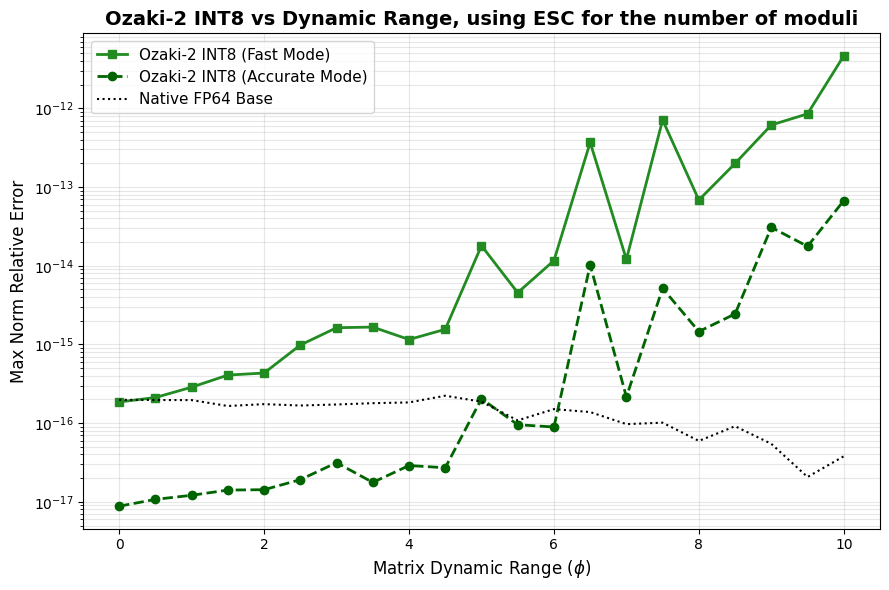

In [4]:
# --- PARAMETERS ---
N = 32
repeats = 10  # Boosted slightly for a cleaner mean line
phi_sweep = np.arange(0.0, 10.1, 0.5)  # Granular sweep over Phi
target_u = 53  # Target precision bits (FP64 parity)

# Storage for simple trend lines
errors_int8_fast = []
errors_int8_acc = []
baseline_f64 = []

def estimate_nb_moduli_for_o2_flat(
    A: npt.NDArray[np.float64], 
    B: npt.NDArray[np.float64], 
    target_bits: int, 
    compute_type: npt.DTypeLike
) -> int:
    """
    Rigorously estimates the exact number of moduli (k) required for full_ozaki_2.
    Accounts for the uniform row/col scaling factors implemented in your source code.
    """
    q = A.shape[1]  # Inner dot-product dimension
    
    # 1. Replicate your library's exact scale calculation logic
    _, exp_A = np.frexp(np.abs(A))
    _, exp_B = np.frexp(np.abs(B))
    max_A = np.max(exp_A, axis=1, keepdims=True)
    max_B = np.max(exp_B, axis=0, keepdims=True)
    
    # The maximum value an entry can take after scaling is 2**target_bits
    # Therefore, the product of any two scaled entries is bounded by 2**(2 * target_bits)
    # Accumulated over q elements, the maximum possible value is q * 2**(2 * target_bits)
    
    # 2. Total precise bit width required for exact integer accumulation
    required_bits = np.log2(q) + (2 * target_bits) + 1.0
    
    # 3. Get the exact effective bits per modulus for your int8 hardware compute path
    dt = np.dtype(compute_type)
    if np.issubdtype(dt, np.integer):
        bits_max_modulus = dt.itemsize * 8 - 1  # 7 bits for int8
    else:
        info = utils.get_dtype_info(compute_type)
        u_inv = 2 ** info['nmant']
        m_max = math.isqrt((4 * u_inv) // q)
        bits_max_modulus = math.floor(math.log2(m_max))
        
    # Amortize signed CRT penalty matching your fallback: (effective_bits - 0.5)
    effective_bits_per_modulus = bits_max_modulus - 0.5
    
    # 4. Compute k
    nb_moduli = int(np.ceil(required_bits / effective_bits_per_modulus))
    
    return max(1, nb_moduli)

warnings.filterwarnings('ignore', category=RuntimeWarning)
print("--- Profiling Ozaki-2 INT8 Precision vs. Variance ---")

for phi in phi_sweep:
    print(f"\rTesting phi = {phi}", end="")
    err_fast_acc = 0.0
    err_acc_acc = 0.0
    err_f64_acc = 0.0

    k = 17

    for _ in range(repeats):
        if phi == 0.0:
            A = utils.random_mean_var_matrix(N, N, np.float64)
            B = utils.random_mean_var_matrix(N, N, np.float64)
        else:
            A = utils.random_phi_matrix(N, N, phi, np.float64)
            B = utils.random_phi_matrix(N, N, phi, np.float64)
            
        perfect = baseline.get_exact_product(A, B, 256)
        
        # Track Native FP64 Baseline
        err_f64_acc += forward_error(A, B, A @ B, C=perfect)
        
        # Execute automated INT8 lines
        try:
            res_fast = o2.full_ozaki_2(A, B, target_u, estimate_nb_moduli_for_o2_flat(A, B, 53, np.int8), np.int8, np.int32)
            err_fast_acc += forward_error(A, B, res_fast, C=perfect)
        except:
            err_fast_acc += np.nan
            
        try:
            res_acc = o2.full_ozaki_2_acc(A, B, target_u, estimate_nb_moduli_for_o2_flat(A, B, 53, np.int8), np.int8, np.int32)
            err_acc_acc += forward_error(A, B, res_acc, C=perfect)
        except:
            err_acc_acc += np.nan

    errors_int8_fast.append(err_fast_acc / repeats)
    errors_int8_acc.append(err_acc_acc / repeats)
    baseline_f64.append(err_f64_acc / repeats)

warnings.filterwarnings('default', category=RuntimeWarning)

# --- SIMPLE LINEAR TREND PLOT ---
fig, ax = plt.subplots(figsize=(9, 6))

ax.semilogy(phi_sweep, errors_int8_fast, color='forestgreen', marker='s', linestyle='-', linewidth=2, label='Ozaki-2 INT8 (Fast Mode)')
ax.semilogy(phi_sweep, errors_int8_acc, color='darkgreen', marker='o', linestyle='--', linewidth=2, label='Ozaki-2 INT8 (Accurate Mode)')
ax.plot(phi_sweep, baseline_f64, color='black', linestyle=':', linewidth=1.5, label='Native FP64 Base')

ax.set_title('Ozaki-2 INT8 vs Dynamic Range, using ESC for the number of moduli', fontsize=14, fontweight='bold')
ax.set_xlabel('Matrix Dynamic Range ($\\phi$)', fontsize=12)
ax.set_ylabel('Max Norm Relative Error', fontsize=12)

ax.grid(True, which="both", ls="-", alpha=0.3)
ax.legend(loc='best', fontsize=11)

plt.tight_layout()
plt.show()

# Conclusion : accurate mode is far better, but for high matrix dynamic range we need far more moduli. Probably dynamic too, like the ESC...

<>:76: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:77: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:76: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:77: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
/tmp/ipykernel_61933/3155457042.py:76: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  ax.set_title('Moduli Depletion Under High Dynamic Range ($\phi$)', fontsize=14, fontweight='bold', pad=15)
/tmp/ipykernel_61933/3155457042.py:77: SyntaxWarning: "\p" is an invalid escape sequence.

--- Profiling Ozaki-2: How Increasing Moduli Rescues High-Phi Volatility ---
Testing phi = 8.0

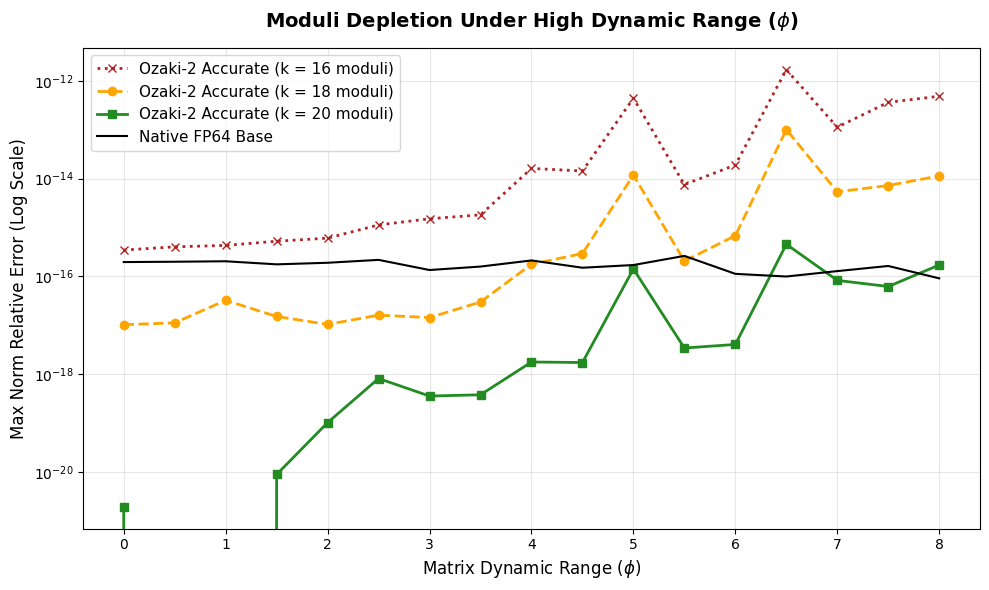

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import warnings

# --- PARAMETERS ---
N = 32
repeats = 5
phi_sweep = np.arange(0.0, 8.1, 0.5)  # Sweep dynamic range
target_u = 53  # Target precision bits

# Choose three fixed moduli counts to show the progression
# For int8 computing with ~6.5 effective bits per modulus:
# k=16 (~104 bits), k=18 (~117 bits), k=20 (~130 bits)
k_variants = [16, 18, 20]

# Storage for the error tracks
# Dictionary mapping k -> list of errors across the phi sweep
errors_by_k = {k: [] for k in k_variants}
baseline_f64 = []

warnings.filterwarnings('ignore', category=RuntimeWarning)
print("--- Profiling Ozaki-2: How Increasing Moduli Rescues High-Phi Volatility ---")

for phi in phi_sweep:
    print(f"\rTesting phi = {phi:.1f}", end="")
    
    # Initialize error accumulators for this phi step
    err_accum_by_k = {k: 0.0 for k in k_variants}
    err_f64_acc = 0.0
    
    for _ in range(repeats):
        if phi == 0.0:
            A = utils.random_mean_var_matrix(N, N, np.float64)
            B = utils.random_mean_var_matrix(N, N, np.float64)
        else:
            A = utils.random_phi_matrix(N, N, phi, np.float64)
            B = utils.random_phi_matrix(N, N, phi, np.float64)
            
        perfect = baseline.get_exact_product(A, B, 256)
        
        # Track Native FP64 baseline
        err_f64_acc += forward_error(A, B, A @ B, C=perfect.astype(np.float64))
        
        # Evaluate each fixed moduli count variant using Accurate Mode
        # to show the dynamic capacity shifting
        for k in k_variants:
            try:
                res = o2.full_ozaki_2_acc(A, B, target_u, int(k), np.int8, np.int32)
                err_accum_by_k[k] += forward_error(A, B, res, C=perfect.astype(np.float64))
            except Exception:
                err_accum_by_k[k] += np.nan

    # Average and store
    baseline_f64.append(err_f64_acc / repeats)
    for k in k_variants:
        errors_by_k[k].append(err_accum_by_k[k] / repeats)

warnings.filterwarnings('default', category=RuntimeWarning)

# --- PLOTTING ---
fig, ax = plt.subplots(figsize=(10, 6))

# Plot lines for each moduli variant
colors = {16: 'firebrick', 18: 'orange', 20: 'forestgreen'}
markers = {16: 'x', 18: 'o', 20: 's'}
styles = {16: ':', 18: '--', 20: '-'}

for k in k_variants:
    ax.semilogy(phi_sweep, errors_by_k[k], 
                color=colors[k], marker=markers[k], linestyle=styles[k], linewidth=2,
                label=f'Ozaki-2 Accurate (k = {k} moduli)')

# Overlay Native FP64
ax.plot(phi_sweep, baseline_f64, color='black', linestyle='-', linewidth=1.5, label='Native FP64 Base')

ax.set_title('Moduli Depletion Under High Dynamic Range ($\phi$)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Matrix Dynamic Range ($\phi$)', fontsize=12)
ax.set_ylabel('Max Norm Relative Error (Log Scale)', fontsize=12)

ax.grid(True, which="both", ls="-", alpha=0.3)
ax.legend(loc='best', fontsize=11)

plt.tight_layout()
plt.show()

<>:69: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:69: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
/tmp/ipykernel_61933/2065186973.py:69: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  plt.xlabel('Matrix Dynamic Range ($\phi$)', fontsize=12)


--- Profiling Ozaki-1 Precision Extremes over Wide Dynamic Range ---
Evaluating Phi = 9.6...

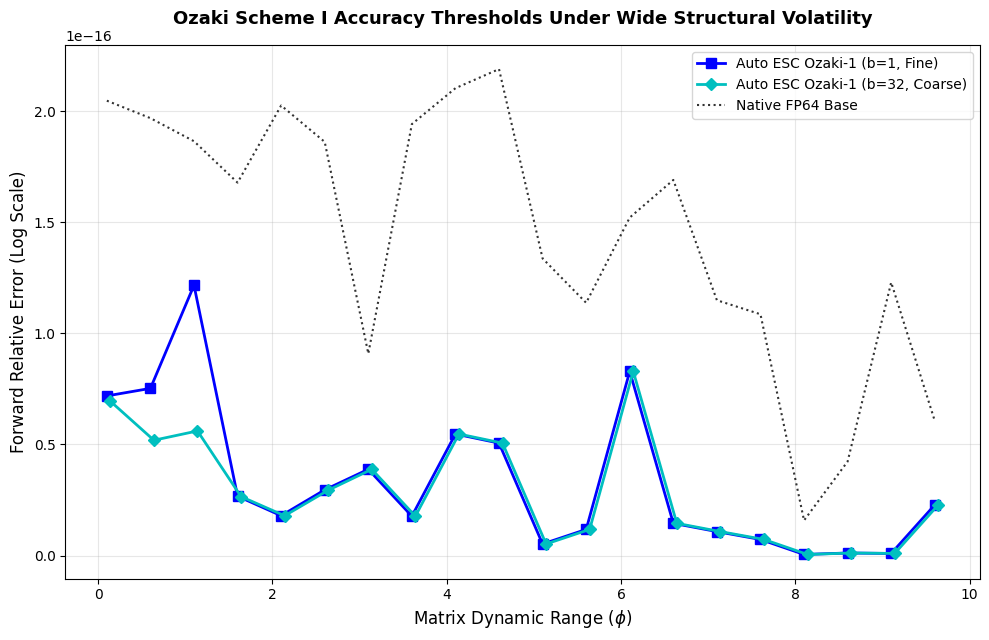

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import warnings

# --- PARAMETERS ---
N = 32
phi_values = np.arange(0.1, 10.1, 0.5)  # Extended dynamic range sweep
repeats = 5

# Hardware/Algorithm parameters
u = 53  # Target precision bits (FP64 parity)
d = 7   # Bits per slice (INT8)

# Accumulators for Errors
error_f64 = []
errors_esc_b1 = []
errors_esc_b32 = []  # Tracking the two extremes

warnings.filterwarnings('ignore', category=RuntimeWarning)
print("--- Profiling Ozaki-1 Precision Extremes over Wide Dynamic Range ---")

for x in phi_values:
    print(f"\rEvaluating Phi = {x:.1f}...", end="")
    
    # Temporary accumulators for averaging current phi level
    err_f64_acc = 0.0
    err_dyn_acc = 0.0
    err_b1_acc = 0.0
    err_b32_acc = 0.0
    
    for _ in range(repeats):
        A = utils.random_phi_matrix(N, N, x, np.float64)
        B = utils.random_phi_matrix(N, N, x, np.float64)

        perfect = baseline.get_exact_product(A, B, 192)
        
        # 1. Standard Floating Point Baseline
        err_f64_acc += forward_error(A, B, A @ B, C=perfect)

        # 3. Fine-Grained ESC Tracking (b=1)
        res_esc_b1 = o1.full_ozaki_1_auto_esc(A, B, np.int8, d, np.int32, b=1)
        err_b1_acc += forward_error(A, B, res_esc_b1, C=perfect)

        # 4. Fully Coarsened ESC Tracking (b=32)
        res_esc_b32 = o1.full_ozaki_1_auto_esc(A, B, np.int8, d, np.int32, b=32)
        err_b32_acc += forward_error(A, B, res_esc_b32, C=perfect)

    # Calculate means
    error_f64.append(err_f64_acc / repeats)
    errors_esc_b1.append(err_b1_acc / repeats)
    errors_esc_b32.append(err_b32_acc / repeats)

warnings.filterwarnings('default', category=RuntimeWarning)

# --- PLOTTING LOGIC ---
plt.figure(figsize=(10, 6.5))

# Define clean spacing for dodging 3 curves across the x-axis
spacing = 0.04
offsets = [-spacing, 0.0, spacing]

# Plot relative forward errors
plt.plot(phi_values + offsets[1], errors_esc_b1, 'b-s', linewidth=2, markersize=7, label='Auto ESC Ozaki-1 (b=1, Fine)')
plt.plot(phi_values + offsets[2], errors_esc_b32, 'c-D', linewidth=2, markersize=6, label='Auto ESC Ozaki-1 (b=32, Coarse)')

# Reference native FP64 line
plt.plot(phi_values, error_f64, color='black', linestyle=':', linewidth=1.5, alpha=0.8, label='Native FP64 Base')

plt.xlabel('Matrix Dynamic Range ($\phi$)', fontsize=12)
plt.ylabel('Forward Relative Error (Log Scale)', fontsize=12)
plt.title('Ozaki Scheme I Accuracy Thresholds Under Wide Structural Volatility', fontsize=13, fontweight='bold', pad=15)
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.legend(loc='best', fontsize=10)

plt.tight_layout()
plt.show()

Running Asymmetric Scaling Precision Isolation: Forward vs. Max Relative...
Evaluating phi_B = 9.6...
Processing complete. Generating comparison figures...


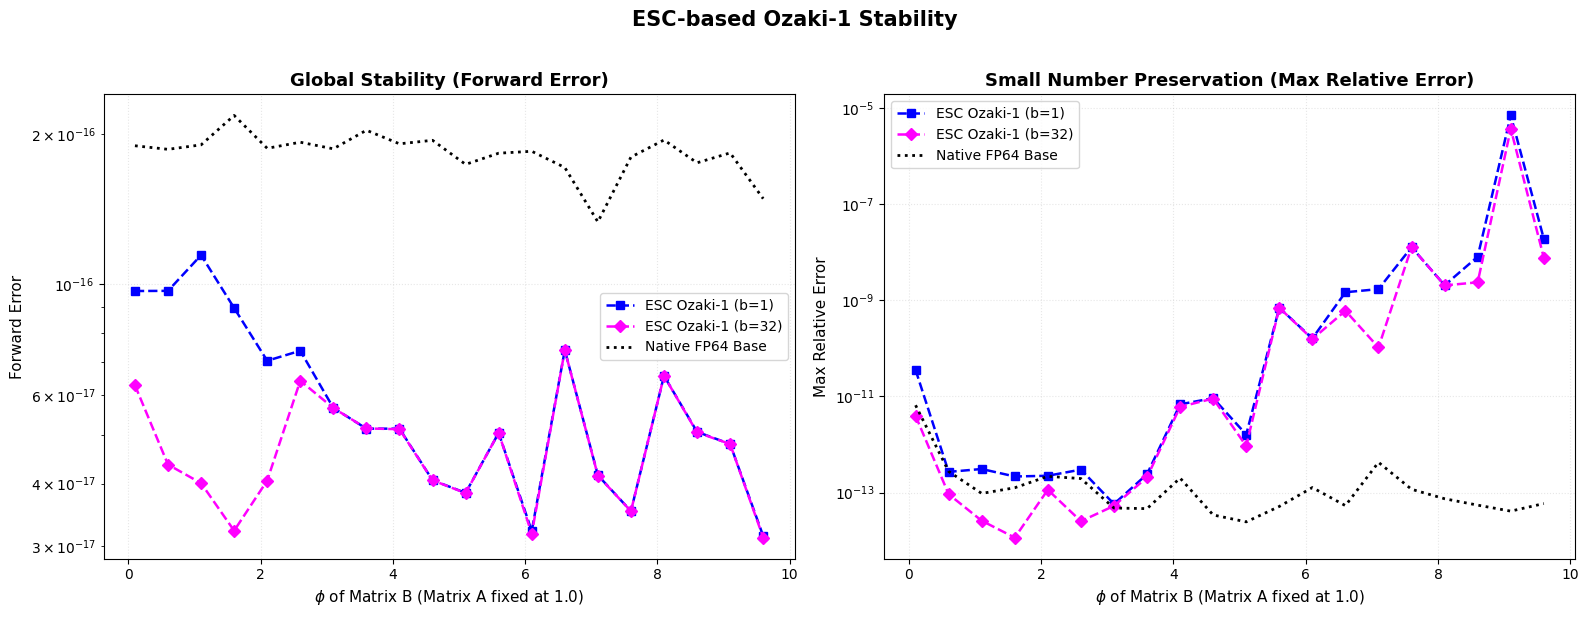

In [9]:
# --- PARAMETERS ---
N = 32
repeats = 10
phi_B_values = np.arange(0.1, 10.1, 0.5)

# Fix Matrix A to be incredibly simple (Low dynamic range)
fixed_phi_A = 1.0

# Hardware/Algorithm parameters
u = 53  
d = 7   

# Track multiple b values for ESC
b_values = [1, 32]

# Accumulators for GLOBAL FORWARD ERROR (Left Plot)
fwd_err_f64 = []
fwd_err_esc_tracks = {b: [] for b in b_values}

# Accumulators for MAX RELATIVE ERROR (Right Plot)
max_rel_f64 = []
max_rel_esc_tracks = {b: [] for b in b_values}

warnings.filterwarnings('ignore', category=RuntimeWarning)
print("Running Asymmetric Scaling Precision Isolation: Forward vs. Max Relative...")

for phi_B in phi_B_values:
    print(f"\rEvaluating phi_B = {phi_B:.1f}...", end="")
    
    # Left plot accumulators
    f_err_f64_acc = 0.0
    f_err_esc_accums = {b: 0.0 for b in b_values}
    
    # Right plot accumulators
    m_err_f64_acc = 0.0
    m_err_esc_accums = {b: 0.0 for b in b_values}
    
    for _ in range(repeats):
        A = utils.random_phi_matrix(N, N, fixed_phi_A, np.float64)
        B = utils.random_phi_matrix(N, N, phi_B, np.float64)
        
        perfect = baseline.get_exact_product(A, B, 256)
        
        # Calculate calculated variants
        res_f64 = A @ B
        
        # 1. Native FP64 Baseline Measurements
        f_err_f64_acc += forward_error(A, B, res_f64, C=perfect)
        m_err_f64_acc += max_relative_error(A, B, res_f64, C=perfect)
        
        # 2. Static Block-Based ESC Multiplications
        for b in b_values:
            res_esc = o1.full_ozaki_1_auto_esc(A, B, np.int8, d, np.int32, b=b)
            
            f_err_esc_accums[b] += forward_error(A, B, res_esc, C=perfect)
            m_err_esc_accums[b] += max_relative_error(A, B, res_esc, C=perfect)

    # Average metrics across repetitions
    fwd_err_f64.append(f_err_f64_acc / repeats)
    max_rel_f64.append(m_err_f64_acc / repeats)
    
    for b in b_values:
        fwd_err_esc_tracks[b].append(f_err_esc_accums[b] / repeats)
        max_rel_esc_tracks[b].append(m_err_esc_accums[b] / repeats)

print("\nProcessing complete. Generating comparison figures...")
warnings.filterwarnings('default', category=RuntimeWarning)

# --- PLOTTING ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

esc_colors = {1: 'blue', 32: 'magenta'}
esc_markers = {1: 's', 32: 'D'}

# ----------------------------------------------------
# Plot 1: Global Forward Error (Left Plot)
# ----------------------------------------------------
for b in b_values:
    ax1.semilogy(phi_B_values, fwd_err_esc_tracks[b], color=esc_colors[b], 
                 marker=esc_markers[b], linestyle='--', linewidth=1.8, 
                 label=f"ESC Ozaki-1 (b={b})")

ax1.plot(phi_B_values, fwd_err_f64, color='black', linestyle=':', linewidth=2, label="Native FP64 Base")

ax1.set_title("Global Stability (Forward Error)", fontsize=13, fontweight='bold')
ax1.set_xlabel(f"$\\phi$ of Matrix B (Matrix A fixed at {fixed_phi_A})", fontsize=11)
ax1.set_ylabel("Forward Error", fontsize=11)
ax1.grid(True, alpha=0.3, linestyle=':')
ax1.legend(loc="best")

# ----------------------------------------------------
# Plot 2: Strict Element-wise Max Relative Error (Right Plot)
# ----------------------------------------------------
for b in b_values:
    ax2.semilogy(phi_B_values, max_rel_esc_tracks[b], color=esc_colors[b], 
                 marker=esc_markers[b], linestyle='--', linewidth=1.8, 
                 label=f"ESC Ozaki-1 (b={b})")

ax2.plot(phi_B_values, max_rel_f64, color='black', linestyle=':', linewidth=2, label="Native FP64 Base")

ax2.set_title("Small Number Preservation (Max Relative Error)", fontsize=13, fontweight='bold')
ax2.set_xlabel(f"$\\phi$ of Matrix B (Matrix A fixed at {fixed_phi_A})", fontsize=11)
ax2.set_ylabel("Max Relative Error", fontsize=11)
ax2.grid(True, alpha=0.3, linestyle=':')
ax2.legend(loc="best")

plt.suptitle("ESC-based Ozaki-1 Stability", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Sweeping Matrix Variance (phi) from 0.1 to 9.6 (Fixed moduli k=12)...
Evaluating phi = 9.6...
Benchmark complete. Generating plot...


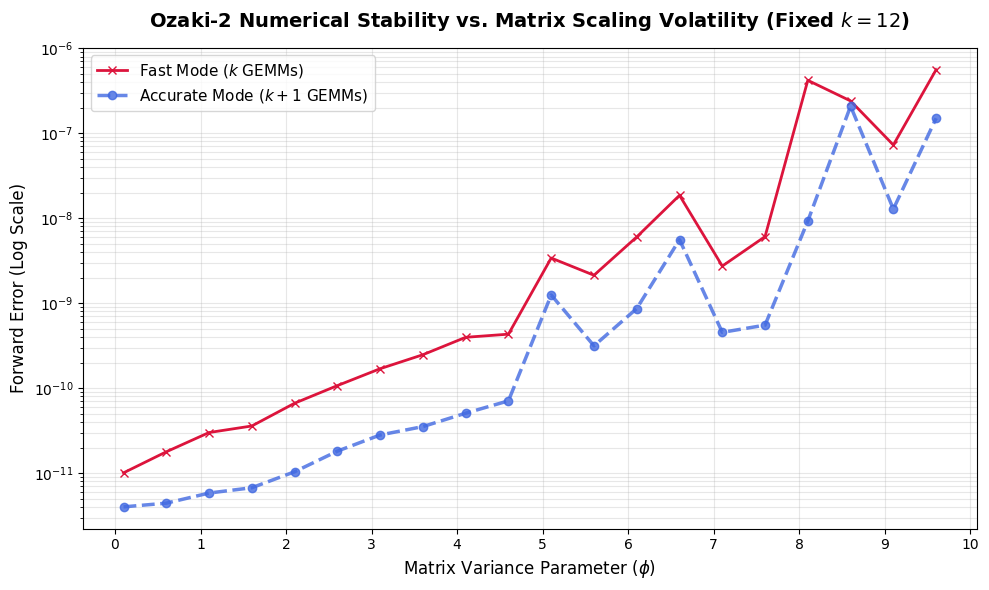

In [13]:
# --- PARAMETERS ---
# Sweeping across Phi with finer steps to capture the precise divergence point
phi_range = np.arange(0.1, 10.1, 0.5)
repeats = 5  # Slightly increased repetitions for a cleaner average line
N = 100

# Fix the number of moduli for a controlled environment
k_fixed = 12  

errors_fast = []
errors_accurate = []

warnings.filterwarnings('ignore', category=RuntimeWarning)
print(f"Sweeping Matrix Variance (phi) from {phi_range[0]} to {phi_range[-1]} (Fixed moduli k={k_fixed})...")

for phi in phi_range:
    print(f"\rEvaluating phi = {phi:.1f}...", end="")
    err_fast_acc = 0.0
    err_acc_acc = 0.0
    
    for r in range(repeats):
        A = utils.random_phi_matrix(N, N, phi, np.float64)
        B = utils.random_phi_matrix(N, N, phi, np.float64)
        perfect = get_exact_product(A, B, 192)
        
        # Calculate max safe precision parameters natively
        moduli = o2.get_moduli_universal(np.int8, k_fixed, q=N)
        cap = sum(math.log2(m) for m in moduli)
        target_bits = max(1, int((cap - np.log2(N) - 1) / 2.0))
        
        # 1. Fast Mode
        try:
            res_fast = o2.full_ozaki_2(A, B, target_bits, k_fixed, np.int8, np.int32)
            err_fast_acc += forward_error(A, B, res_fast, C=perfect)
        except Exception:
            err_fast_acc += np.nan
            
        # 2. Accurate Mode
        try:
            res_acc = o2.full_ozaki_2_acc(A, B, target_bits, k_fixed, np.int8, np.int32)
            err_acc_acc += forward_error(A, B, res_acc, C=perfect)
        except Exception:
            err_acc_acc += np.nan
            
    errors_fast.append(err_fast_acc / repeats)
    errors_accurate.append(err_acc_acc / repeats)

print("\nBenchmark complete. Generating plot...")
warnings.filterwarnings('default', category=RuntimeWarning)

# --- PLOTTING ---
fig, ax = plt.subplots(figsize=(10, 6))

# Use contrasting styles to clearly emphasize the precision gap
ax.semilogy(phi_range, errors_fast, color='crimson', linestyle='-', marker='x', 
            linewidth=2.0, markersize=6, label='Fast Mode ($k$ GEMMs)')
ax.semilogy(phi_range, errors_accurate, color='royalblue', linestyle='--', marker='o', 
            linewidth=2.5, markersize=6, alpha=0.8, label='Accurate Mode ($k+1$ GEMMs)')

ax.set_xlabel('Matrix Variance Parameter ($\\phi$)', fontsize=12)
ax.set_ylabel('Forward Error (Log Scale)', fontsize=12)
ax.set_title(f'Ozaki-2 Numerical Stability vs. Matrix Scaling Volatility (Fixed $k={k_fixed}$)', 
             fontsize=14, fontweight='bold', pad=15)

# Setting structured tick positions across the sweep range
ax.set_xticks(np.arange(0, 11, 1))
ax.grid(True, which="both", ls="-", alpha=0.3)
ax.legend(loc='best', fontsize=11)

plt.tight_layout()
plt.show()